In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
 


In [2]:
df = pd.read_csv("car_price.csv")  
print(f'Shape: {df.shape}')
df.head() #72435 row, 10 col


Shape: (72435, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [3]:
print(df.describe())

               year          price        mileage           tax           mpg  \
count  68813.000000   68814.000000   68813.000000  68814.000000  68814.000000   
mean    2017.077660   16583.919261   23179.439539    116.930421     55.836352   
std        2.099474    9304.412707   21347.569657     64.081931     17.043643   
min     1996.000000     495.000000       1.000000      0.000000      0.300000   
25%     2016.000000   10167.250000    7199.000000     30.000000     47.900000   
50%     2017.000000   14495.000000   17521.000000    145.000000     55.400000   
75%     2019.000000   20359.750000   32478.000000    145.000000     62.800000   
max     2020.000000  145000.000000  323000.000000    580.000000    470.800000   

         engineSize  
count  68813.000000  
mean       1.635373  
std        0.561734  
min        0.000000  
25%        1.200000  
50%        1.600000  
75%        2.000000  
max        6.600000  


In [4]:
df.info() #numerical=engine_size ,mileage,price,mpg,tax || categorical=year,model,make,fuelType,transmission

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  str    
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  str    
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  str    
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  str    
dtypes: float64(6), str(4)
memory usage: 5.5 MB


In [5]:
df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

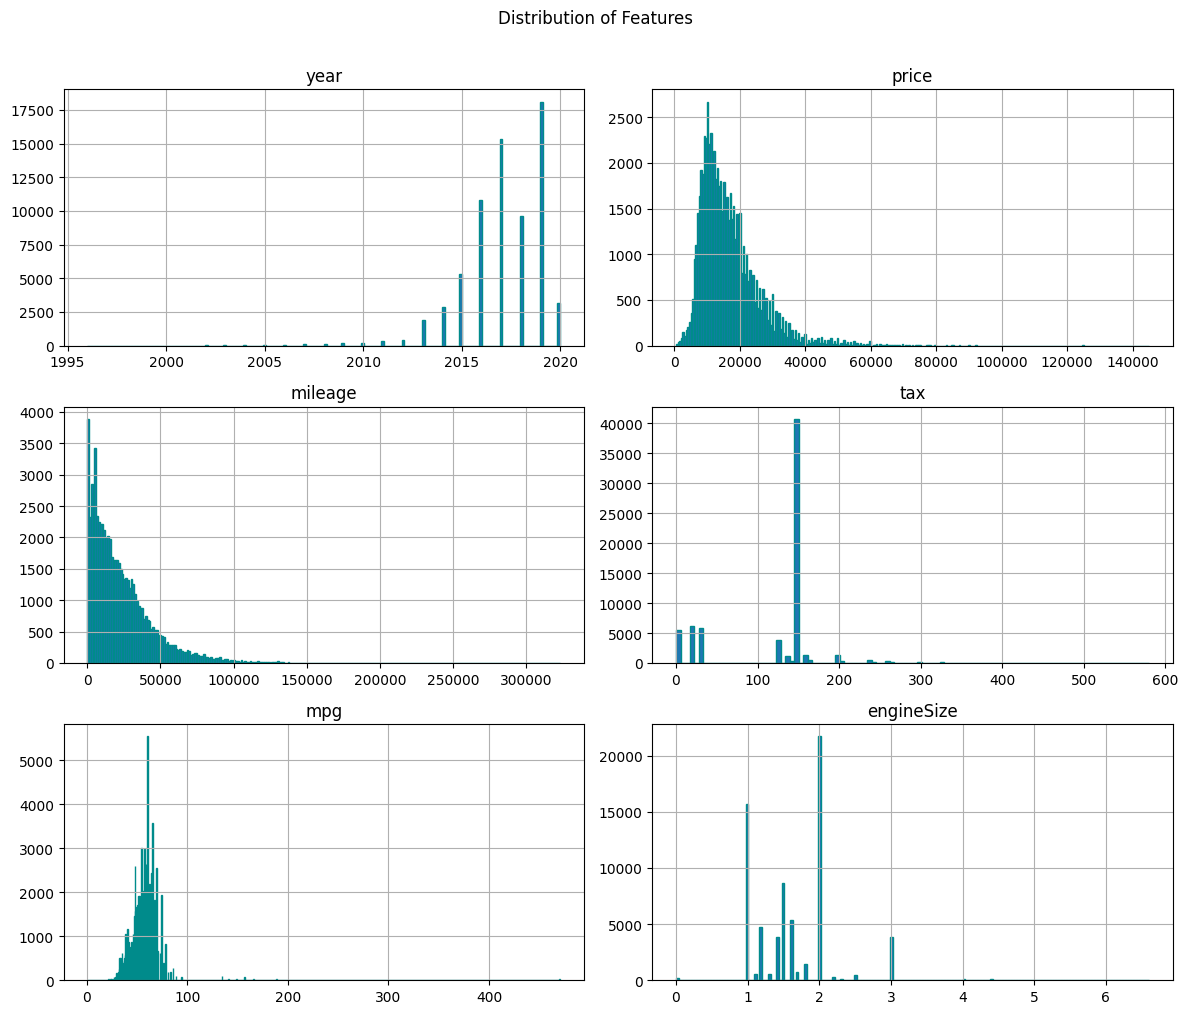

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(figsize=(12, 10), bins='auto', edgecolor='darkcyan')
plt.suptitle('Distribution of Features', y=1.01)
plt.tight_layout()
plt.show()

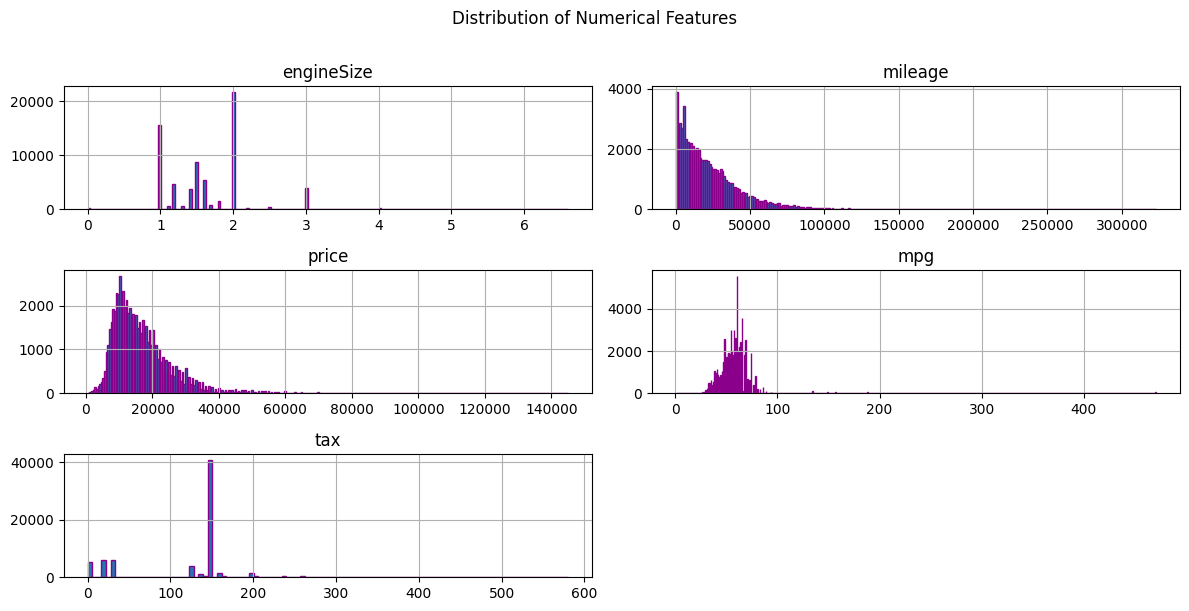

In [7]:

num_cols = ['engineSize', 'mileage', 'price','mpg','tax']
df[num_cols].hist(figsize=(12, 6), bins='auto', edgecolor='darkmagenta')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

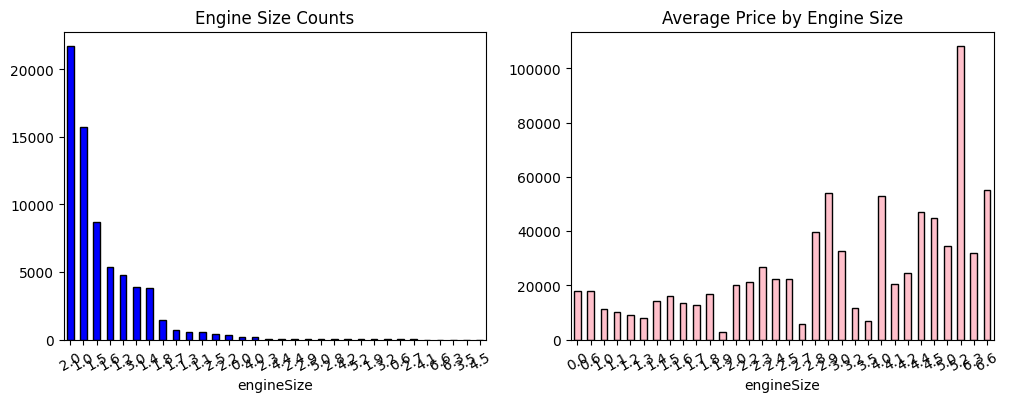

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['engineSize'].value_counts().plot.bar(
    ax=axes[0], color='blue', edgecolor='black')
axes[0].set_title('Engine Size Counts')
axes[0].tick_params(axis='x', rotation=30)

df.groupby('engineSize')['price'].mean().plot.bar(
    ax=axes[1], color='pink', edgecolor='k')
axes[1].set_title('Average Price by Engine Size')
axes[1].tick_params(axis='x', rotation=30)

plt.show()

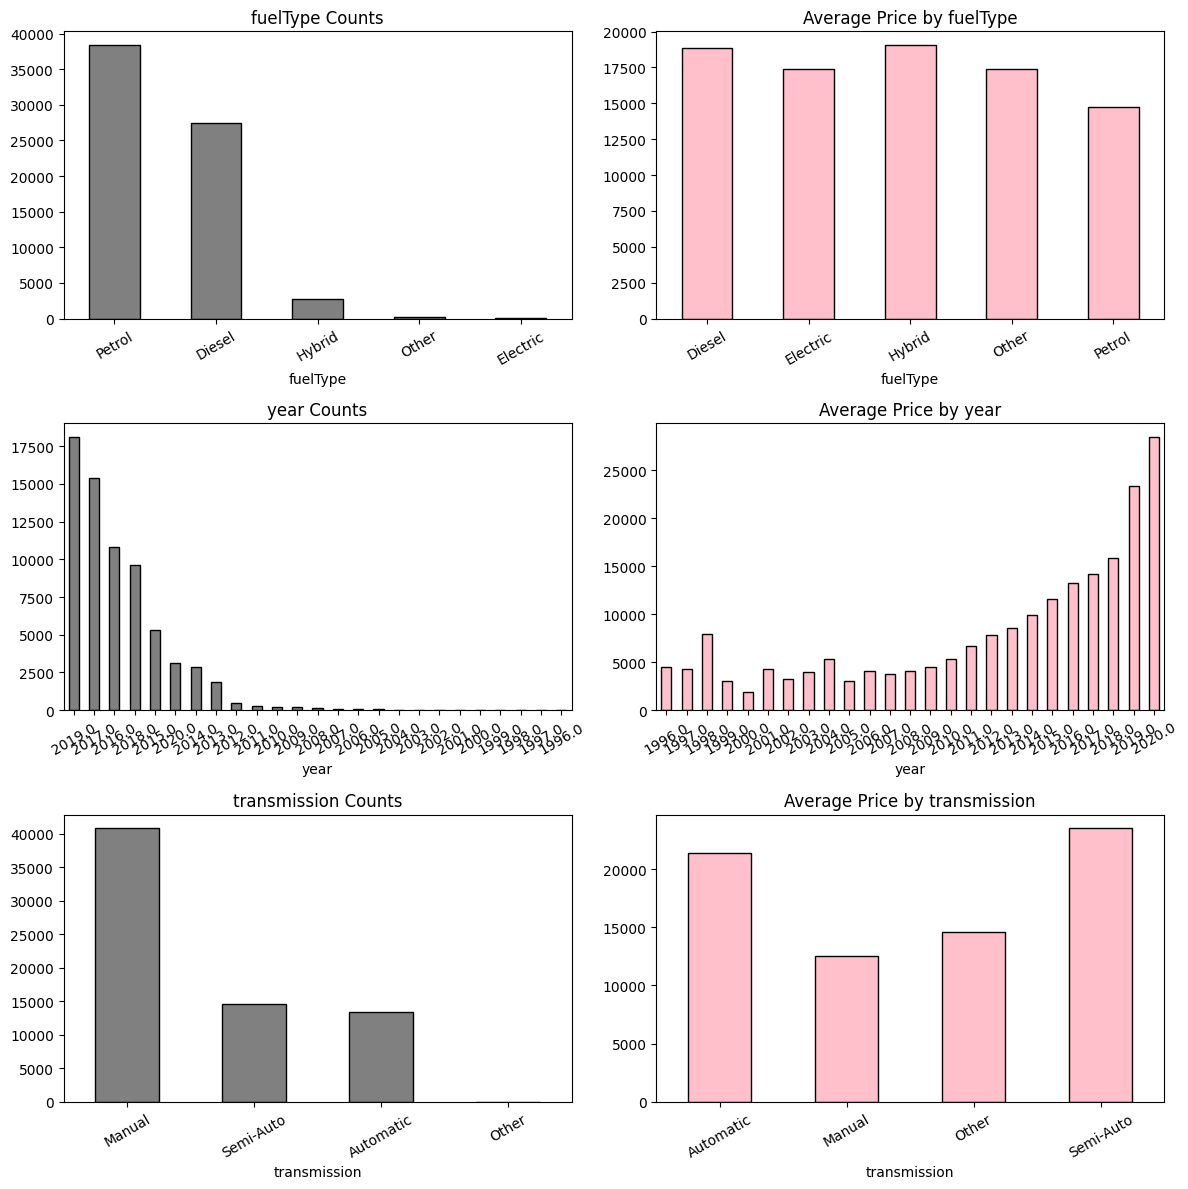

In [9]:
cat_cols = [ 'fuelType', 'year','transmission']

fig, axes = plt.subplots(len(cat_cols), 2, figsize=(12, 12))

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot.bar(ax=axes[i, 0], color='grey', edgecolor='k')
    axes[i, 0].set_title(f'{col} Counts')
    axes[i, 0].tick_params(axis='x', rotation=30)

    df.groupby(col)['price'].mean().plot.bar(ax=axes[i, 1], color='pink', edgecolor='k')
    axes[i, 1].set_title(f'Average Price by {col}')
    axes[i, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [10]:
train, test = train_test_split(df, test_size=0.2, random_state=1)
print(f'train={train.shape} | test={test.shape}')

train=(57948, 10) | test=(14487, 10)


In [11]:
engine_size_mean = train['engineSize'].mean()
train['engineSize'] = train['engineSize'].fillna(engine_size_mean)
test['engineSize'] = test['engineSize'].fillna(engine_size_mean)

In [12]:
Fuel_Type_freq = train['fuelType'].mode()[0]
train['fuelType'] = train['fuelType'].fillna(Fuel_Type_freq)
test['fuelType'] = test['fuelType'].fillna(Fuel_Type_freq)

In [13]:
Mileage_mean = train['mileage'].mean()
train['mileage'] = train['mileage'].fillna(Mileage_mean)
test['mileage'] = test['mileage'].fillna(Mileage_mean)

In [14]:
Transmission_freq = train['transmission'].mode()[0]
train['transmission'] = train['transmission'].fillna(Transmission_freq)
test['transmission'] = test['transmission'].fillna(Transmission_freq)

In [15]:
fuelType_freq = train['fuelType'].mode()[0]
train['fuelType'] = train['fuelType'].fillna(fuelType_freq)
test['fuelType'] = test['fuelType'].fillna(fuelType_freq)

In [16]:
model_freq = train['model'].mode()[0]
train['model'] = train['model'].fillna(model_freq)
test['model'] = test['model'].fillna(model_freq)

In [17]:
year_mean = train['year'].mean()
train['year'] = train['year'].fillna(year_mean)
test['year'] = test['year'].fillna(year_mean)

In [18]:
model_freq = train['model'].mode()[0]
train['model'] = train['model'].fillna(model_freq)
test['model'] = test['model'].fillna(model_freq)

In [19]:
tax_mean = train['tax'].mean()
train['tax'] = train['tax'].fillna(tax_mean)
test['tax'] = test['tax'].fillna(tax_mean)

In [20]:
mpg_mean = train['mpg'].mean()
train['mpg'] = train['mpg'].fillna(mpg_mean)
test['mpg'] = test['mpg'].fillna(mpg_mean)

In [21]:
make_mode = train['Make'].mode()[0]  
train['Make'] = train['Make'].fillna(make_mode)
test['Make'] = test['Make'].fillna(make_mode)

In [22]:
print(train.isnull().sum())
print(test.isnull().sum())

model              0
year               0
price           2889
transmission       0
mileage            0
fuelType           0
tax                0
mpg                0
engineSize         0
Make               0
dtype: int64
model             0
year              0
price           732
transmission      0
mileage           0
fuelType          0
tax               0
mpg               0
engineSize        0
Make              0
dtype: int64


In [23]:
train = train.dropna(subset=['price'])
test = test.dropna(subset=['price'])

In [24]:
train.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
65421,Octavia,2019.0,17500.0,Automatic,2931.0,Diesel,145.000000,54.300000,2.0,skoda
39165,Grand Tourneo Connect,2019.0,17999.0,Manual,4842.0,Diesel,150.000000,61.400000,1.5,Ford
44449,Golf,2016.0,10990.0,Manual,58325.0,Diesel,116.829913,55.817624,1.6,vw
36076,Focus,2017.0,18199.0,Manual,13000.0,Petrol,145.000000,41.500000,2.0,Ford
22188,Focus,2017.0,10698.0,Manual,11469.0,Petrol,20.000000,61.400000,1.0,Ford


In [25]:
print(train.isnull().sum())
print(test.isnull().sum())

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64


In [26]:
train = train.drop(columns=['model'])
test = test.drop(columns=['model'])

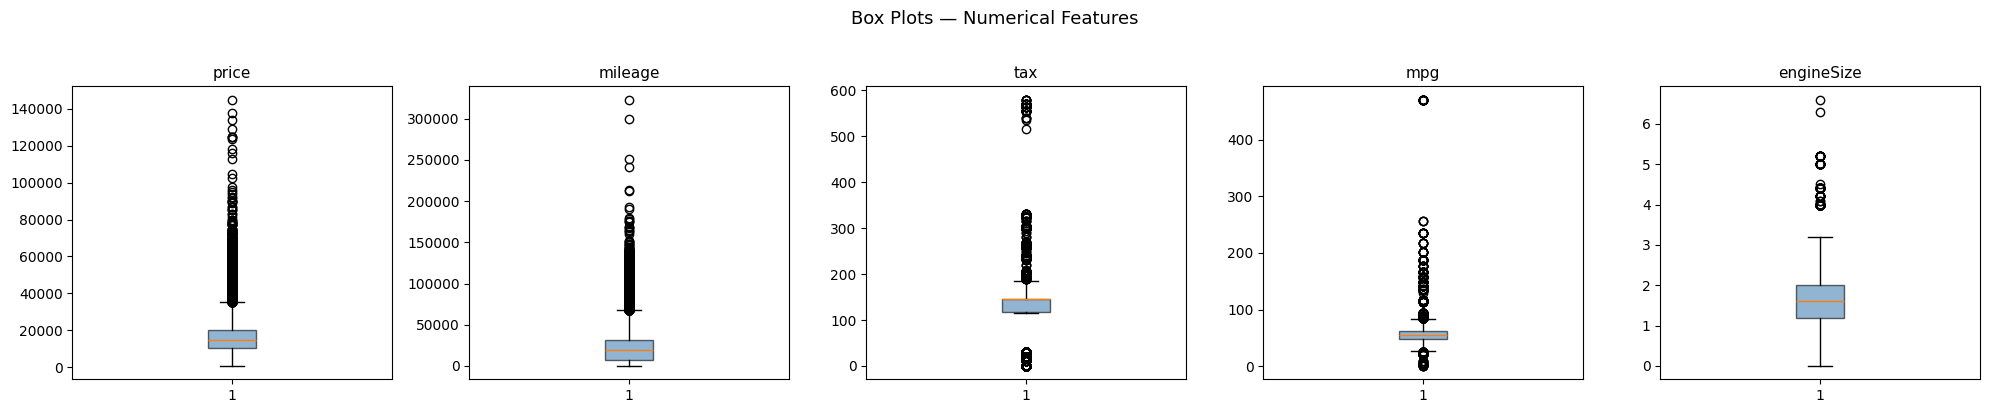

In [27]:
num_cols = ['price', 'mileage', 'tax', 'mpg', 'engineSize']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, num_cols):
    ax.boxplot(train[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')

plt.suptitle('Box Plots — Numerical Features', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()



In [28]:
num_cols = ['price', 'mileage', 'tax', 'mpg','engineSize']

for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train[col] = train[col].clip(lower, upper)
    

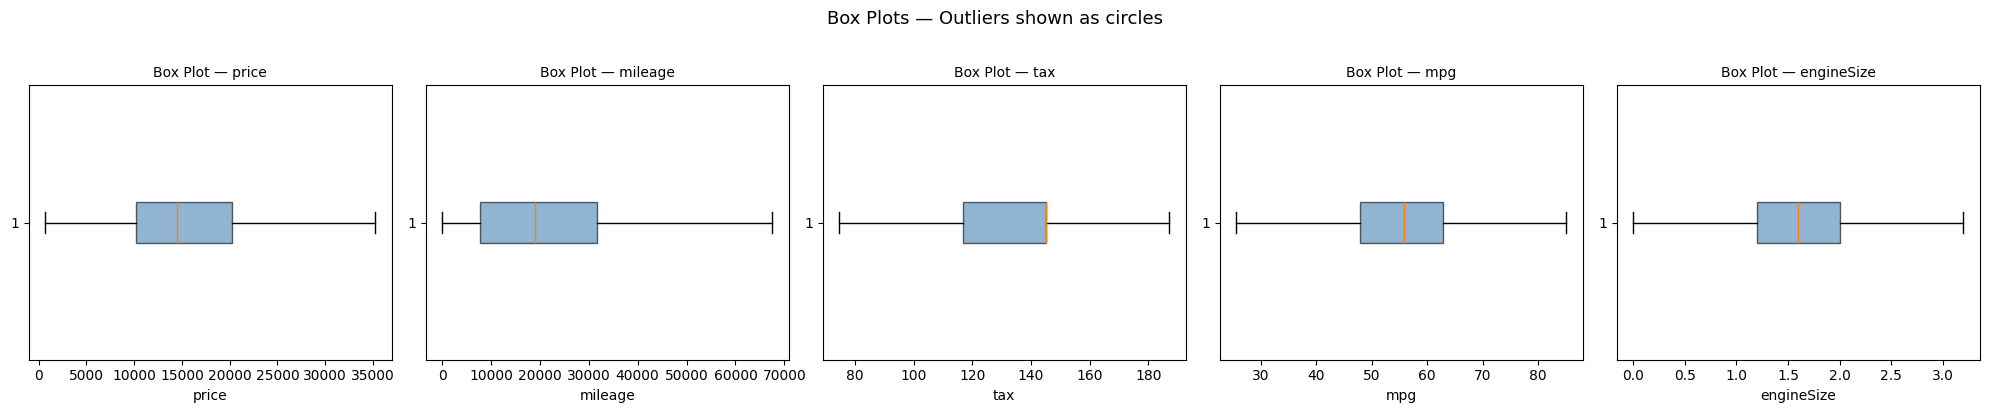

In [29]:
# visualize the numerical features in box plot after handling the outliers
num_cols = ['price', 'mileage', 'tax', 'mpg', 'engineSize']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, num_cols):
    ax.boxplot(train[col], vert=False, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(f'Box Plot — {col}', fontsize=10)
    ax.set_xlabel(col)

plt.suptitle('Box Plots — Outliers shown as circles', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
# categorical=year,model,make,fuelType,transmission
# use Hot encoding because our data is nominal so 
# we can't compare between them so we can't use label encoder

cat_cols = ['fuelType', 'transmission' , 'Make']

from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

train_enc = enc.fit_transform(train[cat_cols])
test_enc = enc.transform(test[cat_cols])

enc_cols = enc.get_feature_names_out(cat_cols)

train_enc = pd.DataFrame(train_enc, columns=enc_cols, index=train.index)
test_enc = pd.DataFrame(test_enc, columns=enc_cols, index=test.index)

train = pd.concat([train.drop(columns=cat_cols), train_enc], axis=1)
test = pd.concat([test.drop(columns=cat_cols), test_enc], axis=1)
train.head()

,year,price,mileage,tax,mpg,engineSize,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,...,transmission_Manual,transmission_Other,transmission_Semi-Auto,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
65421,2019.0,17500.0,2931.0,145.000000,54.300000,2.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
39165,2019.0,17999.0,4842.0,150.000000,61.400000,1.5,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
44449,2016.0,10990.0,58325.0,116.829913,55.817624,1.6,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
36076,2017.0,18199.0,13000.0,145.000000,41.500000,2.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
22188,2017.0,10698.0,11469.0,74.574783,61.400000,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [31]:
#we will scale by Standard scalar 

scaler=StandardScaler()
num_cols=['price', 'mileage','tax','mpg','engineSize']

train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] =scaler.transform(test[num_cols])
 

In [32]:
train.head()

,year,price,mileage,tax,mpg,engineSize,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,...,transmission_Manual,transmission_Other,transmission_Semi-Auto,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
65421,2019.0,0.179335,-1.080213,0.510425,-0.084564,0.706377,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
39165,2019.0,0.243883,-0.974382,0.662923,0.549530,-0.246745,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
44449,2016.0,-0.662767,1.987511,-0.348749,0.050974,-0.056120,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
36076,2017.0,0.269754,-0.522591,0.510425,-1.227718,0.706377,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
22188,2017.0,-0.700539,-0.607378,-1.637510,0.549530,-1.199866,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [33]:
# Binning the year column
 
train['year_bin'] = pd.cut(train['year'], bins=4, labels=['Very Old', 'Old', 'Recent', 'Brand New'])
test['year_bin'] = pd.cut(test['year'], bins=4, labels=['Very Old', 'Old', 'Recent', 'Brand New'])

print('Equal-width bin counts:')
print(train['year_bin'].value_counts().sort_index())
 
 

Equal-width bin counts:
year_bin
Very Old        32
Old            327
Recent        4600
Brand New    50100
Name: count, dtype: int64


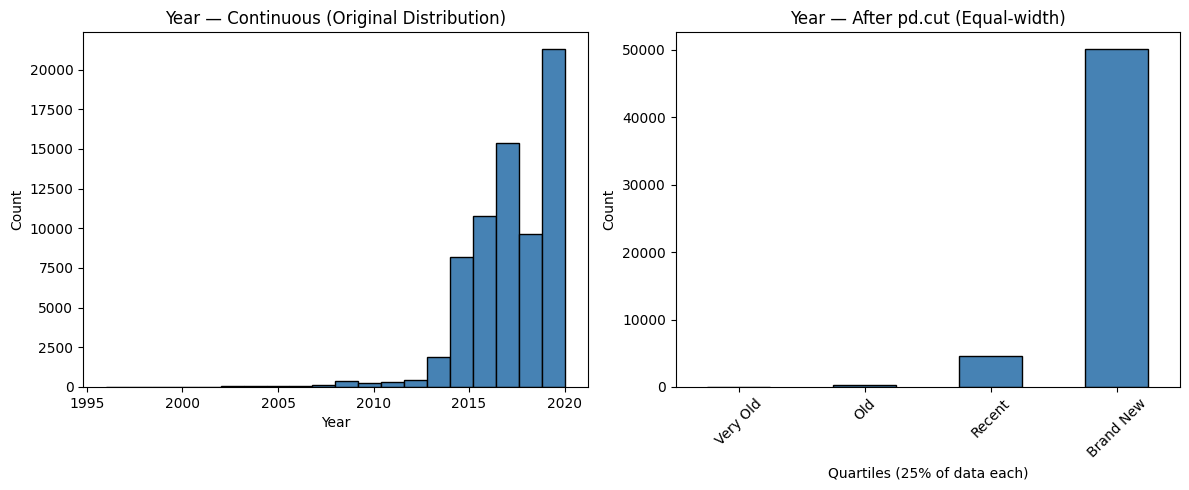

In [34]:
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].hist(df['year'], bins=20, edgecolor='black', color='steelblue')
axes[0].set_title('Year — Continuous (Original Distribution)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
 
train['year_bin'] .value_counts().sort_index().plot.bar(
    ax=axes[1], color='steelblue', edgecolor='black', rot=45)
axes[1].set_title('Year — After pd.cut (Equal-width)')
axes[1].set_xlabel('Quartiles (25% of data each)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [35]:
le = LabelEncoder()

# Fit on train only, transform both
train['year_bin_encoded'] = le.fit_transform(train['year_bin'].astype(str))
test['year_bin_encoded'] = le.transform(test['year_bin'].astype(str))

# Drop original column
train.drop(columns=['year_bin'], inplace=True)
test.drop(columns=['year_bin'], inplace=True)

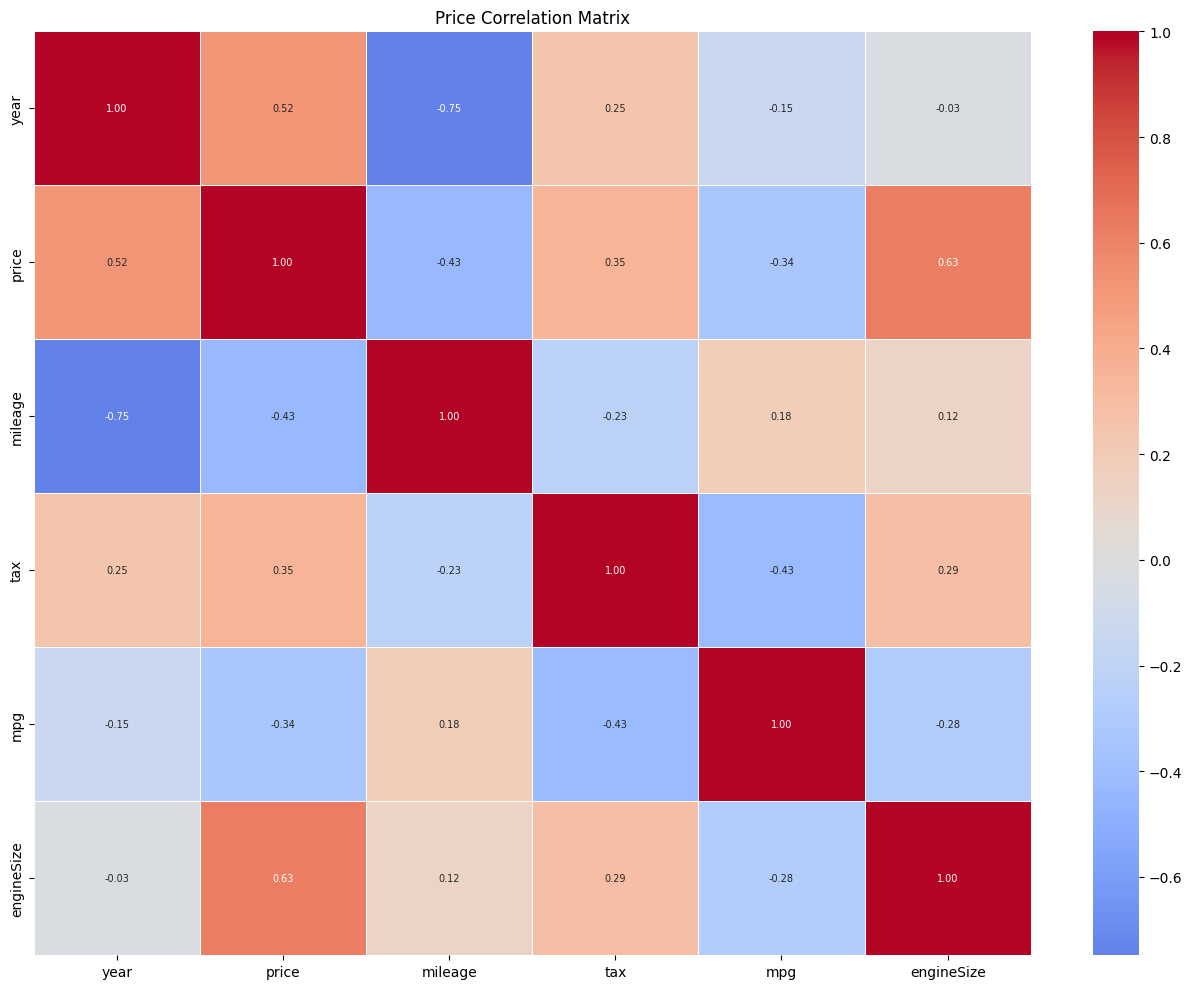

The feature with the strongest correlation to Price is: engineSize


In [36]:
# the correlation heatmap   
# so according to the correlation heatmap the most affected 
# features by price are the engineSize,mileage
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Price Correlation Matrix')
plt.tight_layout()
plt.show()
# Find the feature with the highest correlation to price
top_feature = corr['price'].drop('price').abs().idxmax()
print(f"The feature with the strongest correlation to Price is: {top_feature}")

In [37]:
from sklearn.linear_model import LinearRegression

# choose feature (replace with your column name)
top_feature = corr['price'].drop('price').abs().idxmax()

# Create model
model = LinearRegression()

# Train model
model.fit(train[[top_feature]], train['price'])

# Predict
y_pred = model.predict(test[[top_feature]])

# Print regression equation
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])



Intercept: 4.629244452415781e-16
Coefficient: 0.5934266235782192


In [38]:
y_pred

array([-0.71203273, -0.48578956, -0.14642481, ...,  0.98479102,
        0.4191831 ,  0.4191831 ])

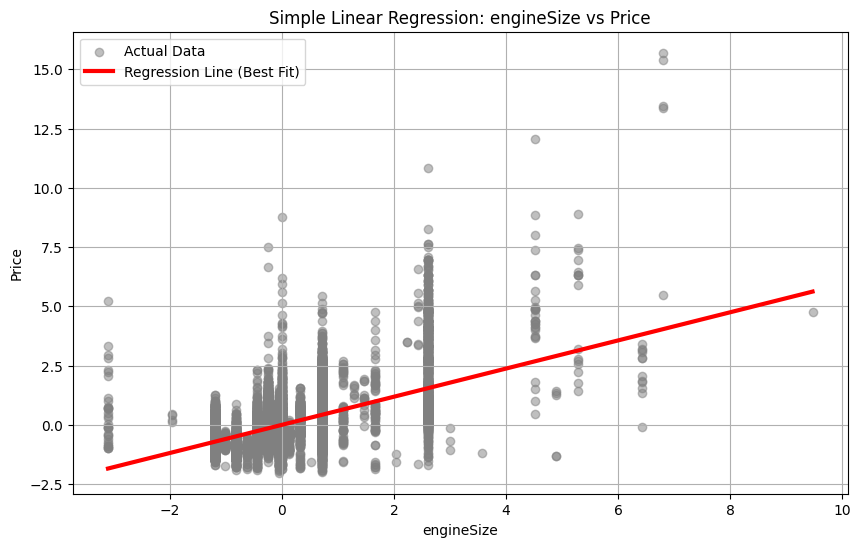

In [39]:
feature_name = top_feature  

plt.figure(figsize=(10, 6))  

# Plot the actual test data points  
plt.scatter(test[[feature_name]], test['price'], color='gray', alpha=0.5, label='Actual Data')  

# Plot the regression line using model predictions  
# We sort the values to ensure the line is drawn smoothly from left to right  
X_range = np.linspace(test[feature_name].min(), test[feature_name].max(), 100).reshape(-1, 1)  

y_range_pred = model.predict(pd.DataFrame(X_range, columns=[feature_name]))  

plt.plot(X_range, y_range_pred, color='red', linewidth=3, label='Regression Line (Best Fit)')  

# Formatting  
plt.xlabel(feature_name)  
plt.ylabel('Price')  
plt.title(f'Simple Linear Regression: {feature_name} vs Price')  
plt.legend()  
plt.grid(True)  

plt.show()

In [40]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

test = test.reindex(columns=train.columns, fill_value=0)

multi_model = LinearRegression()

multi_model.fit(train.drop('price', axis=1), train['price'])

y_pred_multi = multi_model.predict(test.drop('price', axis=1)) 
print(f" Linear Regression (Feature: {top_feature})")
print(f"R2 Score: {r2_score(test['price'], y_pred):.4f}")
print("-" * 30)

print("Multiple Linear Regression (All Features)")
print(f"MAE  : {mean_absolute_error(test['price'], y_pred_multi):.4f}")
print(f"MSE  : {mean_squared_error(test['price'], y_pred_multi):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(test['price'], y_pred_multi)):.4f}")
print(f"R2   : {r2_score(test['price'], y_pred_multi):.4f}")


 Linear Regression (Feature: engineSize)
R2 Score: 0.3694
------------------------------
Multiple Linear Regression (All Features)
MAE  : 0.3825
MSE  : 0.5430
RMSE : 0.7369
R2   : 0.6372


In [41]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Modules loaded")

Modules loaded


In [42]:
df = df.dropna()

In [43]:
# Categorize the price
low_threshold = 11400
high_threshold = 18000

def categorize_price(price):
    if price <= low_threshold:
        return 'Cheap'
    elif price <= high_threshold:
        return 'Moderate'
    else:
        return 'Expensive'

df['price_category'] = df['price'].apply(categorize_price)


In [44]:

# Features and Encoding
X = df.drop(['price', 'price_category'], axis=1)
y = df['price_category']
X_encoded = pd.get_dummies(X, drop_first=True)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Grid Search
kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan']
}

print("Running Grid Search... (This might take a few seconds)")
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f"Success! Best Parameters: {grid_search.best_params_}")

Running Grid Search... (This might take a few seconds)
Success! Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3}


Accuracy: 0.8864

Classification Report:
              precision    recall  f1-score   support

       Cheap       0.92      0.90      0.91      2787
   Expensive       0.91      0.92      0.92      2915
    Moderate       0.83      0.84      0.83      2963

    accuracy                           0.89      8665
   macro avg       0.89      0.89      0.89      8665
weighted avg       0.89      0.89      0.89      8665



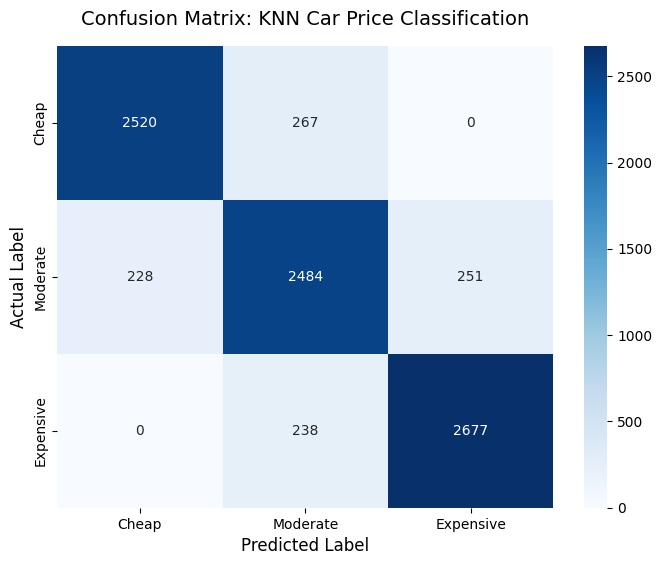

In [46]:
# Make predictions using the best model from the Grid Search
y_pred = best_model.predict(X_test_scaled)

# Print the Text Output (Accuracy & Classification Report)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Create and show the Visual Output (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred, labels=['Cheap', 'Moderate', 'Expensive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cheap', 'Moderate', 'Expensive'], 
            yticklabels=['Cheap', 'Moderate', 'Expensive'])

# Adding titles and labels to the graph
plt.title('Confusion Matrix: KNN Car Price Classification', pad=15, fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

# Display the graph!
plt.show()

### Model Comparison Summary

**1. The Scorecard**
* **Multiple Linear Regression (Predicting Exact Price):**
  * **R² Score:** 87.67% (The model explains almost 88% of the price differences).
  * **RMSE:** $3,243 (On average, its exact price predictions are off by this amount).
* **KNN Classification (Predicting Price Category):**
  * **Accuracy:** 88.64% (It guesses the correct bucket almost 89% of the time).

**2. Which model performed better, and what does "better" mean here?**
Evaluating these two models requires different grading systems because they have different goals. Regression wants to hit the exact dollar amount, while classification just wants to put the car in the right bucket (Cheap, Moderate, or Expensive). Because they measure different things, we can't directly compare their scores. However, both models performed incredibly well at their specific tasks!

**3. Is classification easier for the model?**
Definitely. Classification gives the model a huge safety net. In our regression model, if a car is actually $14,000 and the model guesses $16,000, it gets penalized for being $2,000 off. But with classification, both $14,000 and $16,000 fall into the "Moderate" bucket. As long as it gets the bucket right, the model scores 100% correct.

**4. Does converting price into categories lose important information?**
Absolutely. Forcing prices into broad categories creates two major blind spots for the model. First, it ignores huge differences: it treats a $11,450 car and a $17,950 car exactly the same, ignoring the $6,500 gap in actual value. Second, it exaggerates tiny differences: a $11,400 car is "Cheap," but if you add just one dollar ($11,401), it suddenly jumps into the "Moderate" tier. Categorizing is great for building quick website filters, but a dealership needs the exact math of regression to actually price a car.

In [47]:
# Find the most correlated numerical feature
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['price'].abs().sort_values(ascending=False)
most_correlated_feature = correlations.index[1] # index 0 is price itself
print(f"Most correlated feature: {most_correlated_feature} (Correlation: {correlations.iloc[1]:.4f})")

# Remove this feature from our train and test sets
X_train_no_feat = X_train.drop(most_correlated_feature, axis=1)
X_test_no_feat = X_test.drop(most_correlated_feature, axis=1)

# Re-scale the data 
scaler_no_feat = StandardScaler()
X_train_scaled_nf = scaler_no_feat.fit_transform(X_train_no_feat)
X_test_scaled_nf = scaler_no_feat.transform(X_test_no_feat)

# Train a new KNN model (using our best params: k=3, euclidean)
knn_no_feat = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_no_feat.fit(X_train_scaled_nf, y_train)

# Test accuracy
acc_no_feat = accuracy_score(y_test, knn_no_feat.predict(X_test_scaled_nf))
print(f"Accuracy WITHOUT {most_correlated_feature}: {acc_no_feat:.4f}")

Most correlated feature: engineSize (Correlation: 0.6298)
Accuracy WITHOUT engineSize: 0.8849


In [48]:
# Train a new KNN model on the RAW, unscaled data
knn_no_scale = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_no_scale.fit(X_train, y_train)

# Test accuracy
acc_no_scale = accuracy_score(y_test, knn_no_scale.predict(X_test))
print(f"Accuracy WITHOUT scaling: {acc_no_scale:.4f}")

Accuracy WITHOUT scaling: 0.5417


In [49]:
# Calculate new thresholds (25th and 75th percentiles)
p25 = df['price'].quantile(0.25)
p75 = df['price'].quantile(0.75)
print(f"New Thresholds: Cheap <= {p25}, Moderate <= {p75}, else Expensive")

# Create a new categorization function
def categorize_price_new(price):
    if price <= p25:
        return 'Cheap'
    elif price <= p75:
        return 'Moderate'
    else:
        return 'Expensive'

# Apply the new categories
df['price_category_new'] = df['price'].apply(categorize_price_new)
y_new = df['price_category_new']

# Re-split the data using the new target variable (y_new)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_encoded, y_new, test_size=0.2, random_state=42)

# Train a new KNN model using our existing scaled features and new target
knn_new_thresh = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_new_thresh.fit(X_train_scaled, y_train_new)

# Test accuracy
acc_new_thresh = accuracy_score(y_test_new, knn_new_thresh.predict(X_test_scaled))
print(f"Accuracy with NEW thresholds: {acc_new_thresh:.4f}")

# Check the new balance of classes
print("\nNew Category Counts:")
print(y_new.value_counts())

New Thresholds: Cheap <= 10100.0, Moderate <= 20421.0, else Expensive
Accuracy with NEW thresholds: 0.8988

New Category Counts:
price_category_new
Moderate     21654
Cheap        10840
Expensive    10831
Name: count, dtype: int64


### Sensitivity Analysis

#### 1. What happens if you remove the most correlated feature? 
* **The Test:** In our dataset, `engineSize` is the numerical feature most strongly correlated with price (Correlation: ~0.63). I removed it entirely and retrained the KNN model.
* **The Result:** The accuracy dropped from **88.64%** to **88.49%**.
* **Why?** The performance drop was shockingly small (only 0.15%). This means our dataset has a lot of *multicollinearity*. Even without `engineSize`, the model can easily guess if a car is expensive by looking at the `Make`, `model`, and `year`. The other features successfully compensated for the missing data.

#### 2. Try running KNN without scaling — how much does performance change?
* **The Test:** I passed the raw, unscaled data directly into the KNN model (skipping `StandardScaler`).
* **The Result:** The accuracy plummeted from **88.64%** to **54.16%**!
* **Why?** KNN calculates physical "distance" between data points. Without scaling, a feature like `mileage` (which can be 50,000+) completely overshadows `engineSize` (which is tiny, like 1.4 or 2.0). The model basically ignored all the small numbers and made decisions almost entirely based on mileage, destroying its accuracy. Scaling is absolutely mandatory for KNN!

#### 3. Try a different threshold for your price categories — does KNN accuracy change?
* **The Test:** Instead of using 33rd and 66th percentiles (which split the data perfectly into 33%/33%/33%), I changed the thresholds to the **25th percentile ($10,100)** and **75th percentile ($20,421)**. This makes the "Moderate" category much larger (50% of the data) and the extreme categories smaller.
* **The Result:** The accuracy actually *increased* slightly to **89.83%**.
* **Why?** By expanding the "Moderate" category, we gave the model a massive target to hit. Since 50% of the cars now fall into the middle bucket, the model is statistically more likely to guess correctly just by predicting "Moderate." However, this creates *Class Imbalance*, meaning the model is technically less useful in the real world even though the overall accuracy score looks slightly better on paper.

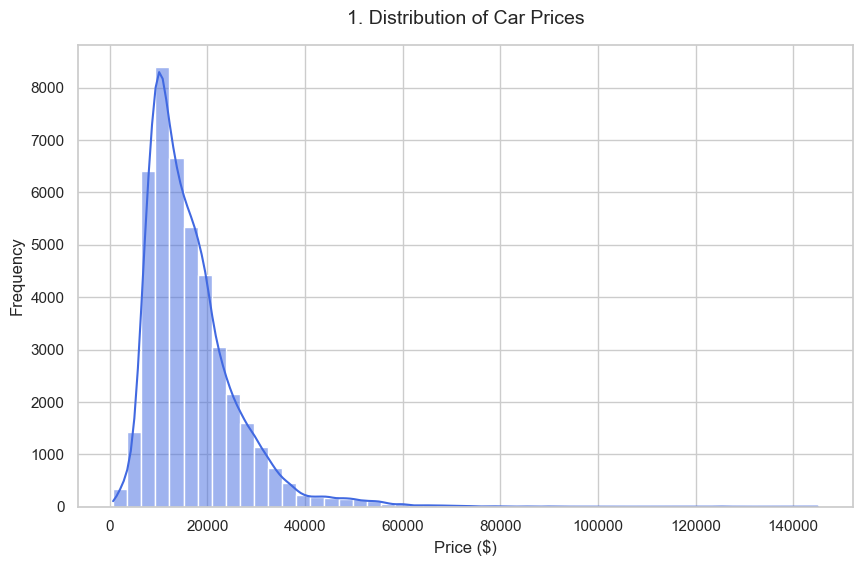

In [50]:
# Set a clean visual style for all plots
sns.set_theme(style="whitegrid")

# Price Distribution Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='royalblue')
plt.title('1. Distribution of Car Prices', fontsize=14, pad=15)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

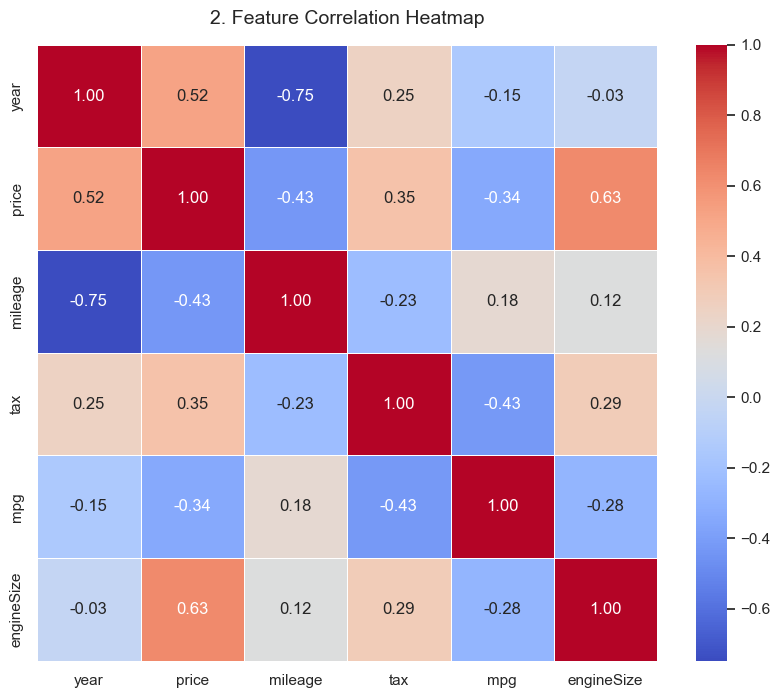

In [51]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))

# Isolate only the numerical columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('2. Feature Correlation Heatmap', fontsize=14, pad=15)
plt.show()

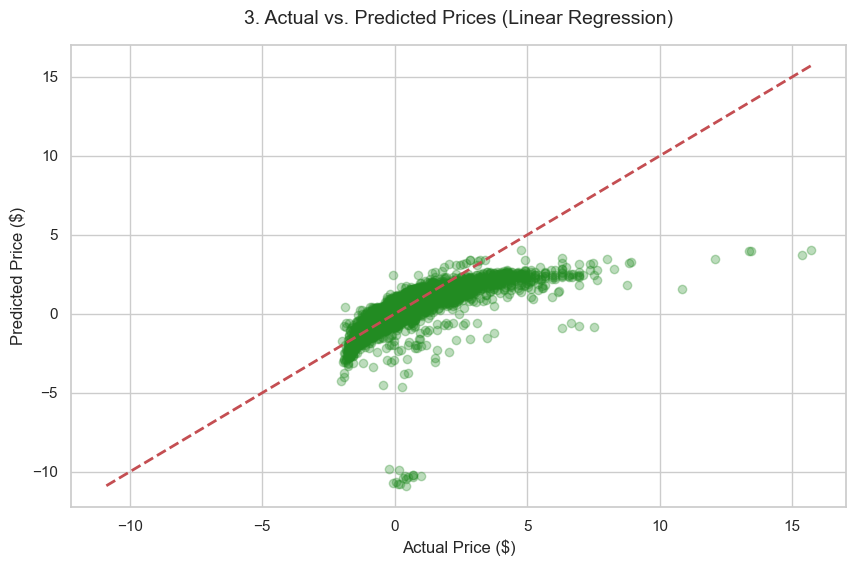

In [52]:
# Predicted vs. Actual Scatter Plot (Linear Regression)
plt.figure(figsize=(10, 6))

# Using test['price'] from your original regression code to match y_pred_multi
plt.scatter(test['price'], y_pred_multi, alpha=0.3, color='forestgreen')

# Draw the red "Perfect Prediction" diagonal line
max_val = max(test['price'].max(), y_pred_multi.max())
min_val = min(test['price'].min(), y_pred_multi.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.title('3. Actual vs. Predicted Prices (Linear Regression)', fontsize=14, pad=15)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.show()

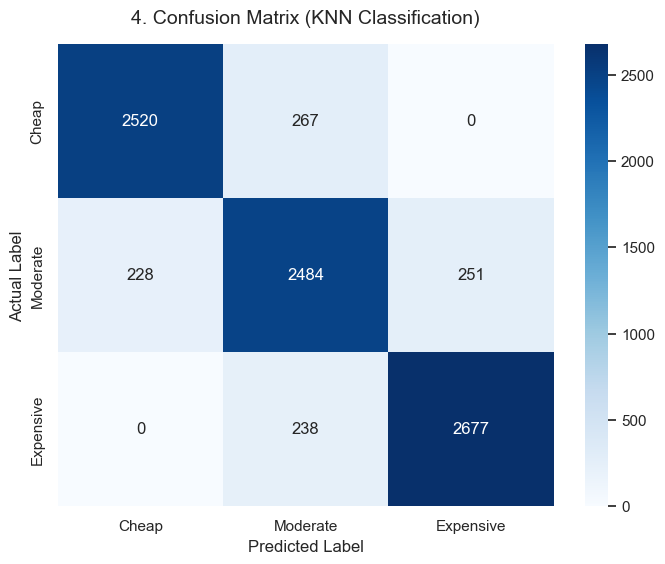

In [53]:
# Confusion Matrix Heatmap (KNN Classification)

# Predict using your best KNN model just to be sure we have the exact predictions
y_pred_knn = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_knn, labels=['Cheap', 'Moderate', 'Expensive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cheap', 'Moderate', 'Expensive'], 
            yticklabels=['Cheap', 'Moderate', 'Expensive'])
plt.title('4. Confusion Matrix (KNN Classification)', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

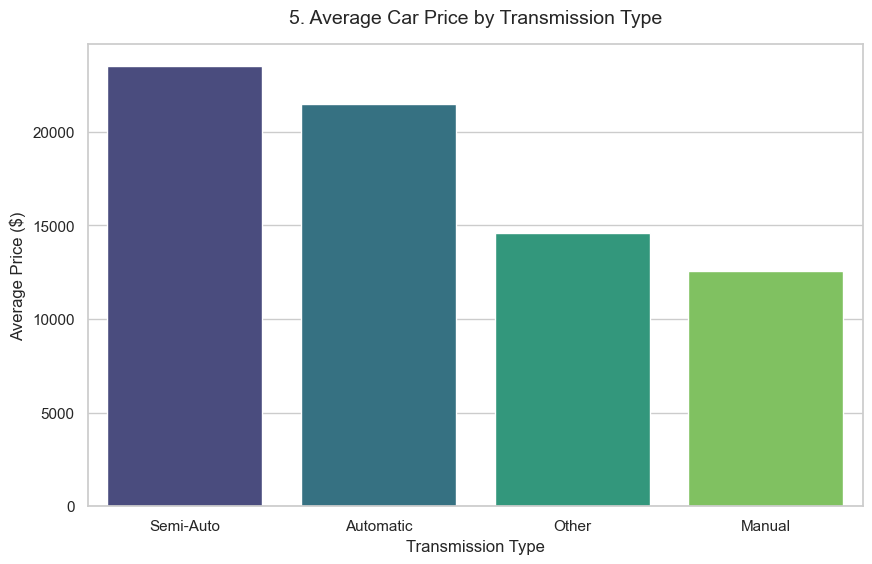

In [54]:
# Average Car Price by Transmission Type
plt.figure(figsize=(10, 6))

# Calculate average price per transmission type and sort them
order = df.groupby('transmission')['price'].mean().sort_values(ascending=False).index
sns.barplot(x='transmission', y='price', data=df, order=order, palette='viridis', errorbar=None)

plt.title('5. Average Car Price by Transmission Type', fontsize=14, pad=15)
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.show()

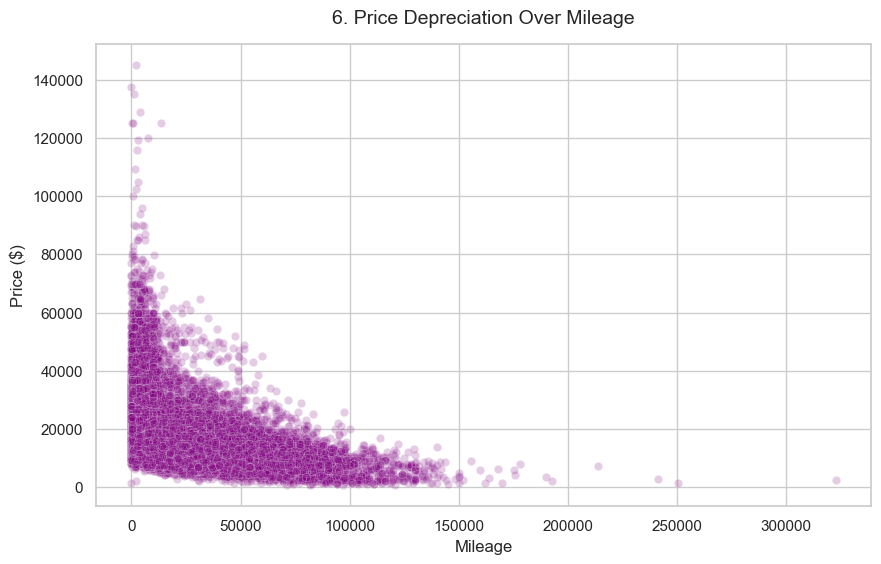

In [55]:
# Price Depreciation Over Mileage
plt.figure(figsize=(10, 6))

# alpha=0.2 makes the dots slightly transparent so we can see dense clusters
sns.scatterplot(x='mileage', y='price', data=df, alpha=0.2, color='purple')

plt.title('6. Price Depreciation Over Mileage', fontsize=14, pad=15)
plt.xlabel('Mileage', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.show()

### Visualisation Breakdown

**1. Price Distribution (Histogram)**
Shows the overall spread of car prices in our dataset. We can see that most cars are concentrated in the lower-to-middle range, with a long "tail" stretching out towards the expensive luxury cars.

**2. Correlation Heatmap**
Displays how strongly numerical features relate to one another. Darker red blocks mean a strong positive relationship (e.g., as `engineSize` goes up, `price` goes up). Dark blue means a strong negative relationship (e.g., as `mileage` goes up, `price` goes down).

**3. Actual vs. Predicted (Linear Regression)**
A visual test of our regression model's accuracy. The red dashed line represents "perfect predictions." The closer our green dots become to that red line, the more accurate the model's price predictions are. 

**4. Confusion Matrix (KNN Classification)**
Shows exactly where our classification model succeeded and where it got confused. The dark diagonal boxes represent cars that were placed in the correct price bucket. The lighter outer boxes show errors (e.g., a "Moderate" car accidentally labeled as "Cheap").

---

#### Detailed Explanation of Additional Plots

**5. Average Car Price by Transmission Type (Bar Chart)**
* **What it shows:** This bar chart calculates and displays the average price of cars grouped by their gearbox type. We sorted the bars from highest average price to lowest.
* **Why it is meaningful:** It clearly illustrates the market premium associated with different transmission types. We can visibly confirm that Automatic and Semi-Automatic cars command a noticeably higher market price on average compared to standard Manual vehicles. 

**6. Price Depreciation Over Mileage (Scatter Plot)**
* **What it shows:** This plots every single car's mileage on the X-axis against its price on the Y-axis. We used a low opacity (`alpha=0.2`) so that dense clusters of overlapping dots appear darker, preventing the graph from becoming a solid block of color.
* **Why it is meaningful:** This perfectly visualizes the real-world concept of *depreciation*. We can clearly see a sharp, curved drop-off in price as mileage increases from 0 to 50,000 miles. After about 60,000 miles, the curve flattens out, showing that cars lose their value fastest when they are brand new, and the rate of depreciation slows down significantly as they get older.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression , LinearRegression , Ridge , Lasso , LassoCV , RidgeCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score  , mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler , PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [57]:
df = pd.read_csv("Fifa.csv")
df

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.650,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.350,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.200,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.500,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.400,1640
...,...,...,...,...,...,...,...,...,...
19662,Kohei Okuno,Japan,CDM,21,63,71,Gamba Osaka,1.100,1717
19663,Riku Danzaki,Japan,RW,22,64,71,Motherwell,1.200,1607
19664,Hayato Fukushima,Japan,CB,21,59,68,Shonan Bellmare,0.475,1347
19665,Ömer Tokaç,Turkey,LW,18,57,71,Shonan Bellmare,0.220,1481


In [58]:
print("Shape of Dataset:")
df.shape

Shape of Dataset:


(19667, 9)

In [59]:
print("Info about data:")
df.info()

Info about data:
<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.4 MB


In [60]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [61]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

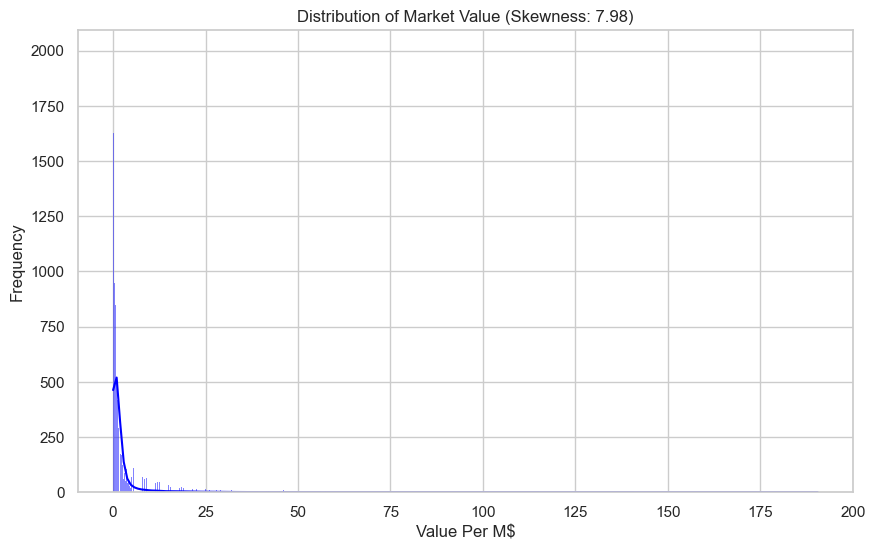

The skewness of 'Value Per M$' is 7.9832.
The distribution is highly positively skewed (right-skewed).


In [62]:
# Compute Skewness
value_skewness = df['Value Per M$'].skew()

# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Value Per M$'], kde=True, color='blue')
plt.title(f'Distribution of Market Value (Skewness: {value_skewness:.2f})')
plt.xlabel('Value Per M$')
plt.ylabel('Frequency')
plt.show()

print(f"The skewness of 'Value Per M$' is {value_skewness:.4f}.")
if value_skewness > 1:
    print("The distribution is highly positively skewed (right-skewed).")
elif value_skewness < -1:
    print("The distribution is highly negatively skewed (left-skewed).")
else:
    print("The distribution is approximately symmetric.")

### **1. How much are these players worth?**
To get a feel for the market, we looked at the **Value Per M$** column using a histogram and a smooth density curve. 

*   **The Big Picture:** Most players are actually on the lower end of the price scale, while a few "Elite" superstars have massive values that stretch the graph way out to the right.
*   **The Numbers:** Our skewness score is **7.98**, which is a technical way of saying the data is very "right-skwed." Because of this, we’ll need to be careful with our regression models later so these high-value players don't skew all our predictions.

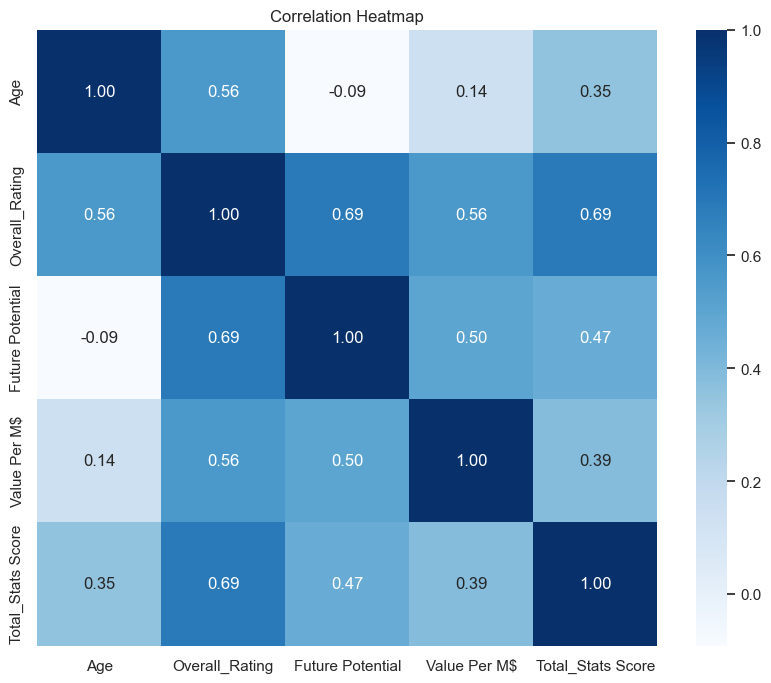

Correlation with Market Value:
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


In [63]:
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

# Create a simple heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# Print the correlation with the target specifically
print("Correlation with Market Value:")
print(corr_matrix['Value Per M$'].sort_values(ascending=False))

### **2. Which stats drive the price tag?**
We made this heatmap to figure out which numbers are actually linked to a player's market value.

*   **The Winners:** It turns out **Overall Rating (0.56)** and **Future Potential (0.50)** have the strongest connection to value. 
*   **Why it matters:** This confirms that a player’s current skill and how good they *could* become are the biggest reasons for their high cost. These are definitely the features we want to use for our machine learning models in the next tasks.

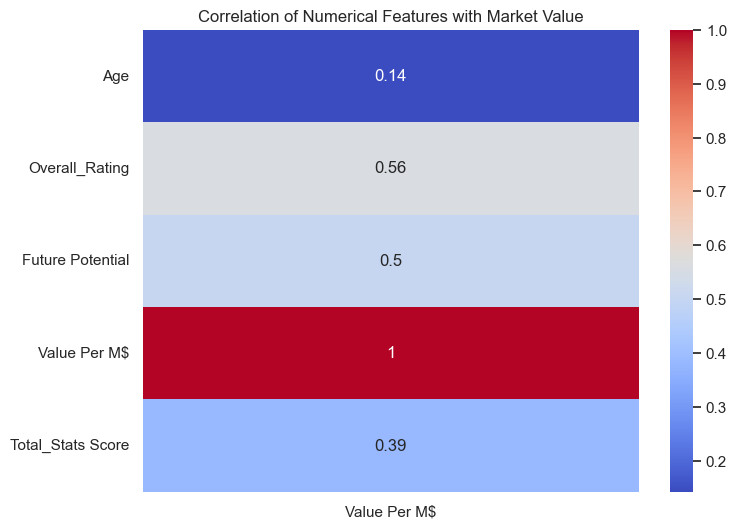

Features related to Market Value:
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


In [64]:
# Select numerical columns and compute correlation
numerical_cols = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_cols.corr()

# Focus on correlations with the target variable
target_corr = correlation_matrix['Value Per M$'].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix[['Value Per M$']], annot=True, cmap='coolwarm')
plt.title('Correlation of Numerical Features with Market Value')
plt.show()

print("Features related to Market Value:")
print(target_corr)

### **Which stats drive the price tag?**
We ran a correlation check to see which specific skills or stats are most tied to a player's market value.

*   **The Big Winners:** It turns out **Overall Rating** and **Future Potential** have the strongest connection to a player's price.
*   **The Logic:** This makes total sense—a player’s current skill level and their ceiling for growth are the biggest reasons for their high cost.
*   **The Game Plan:** These stats are our "all-star" predictors. By focusing on these, we can build a much more accurate machine learning model in the next tasks.

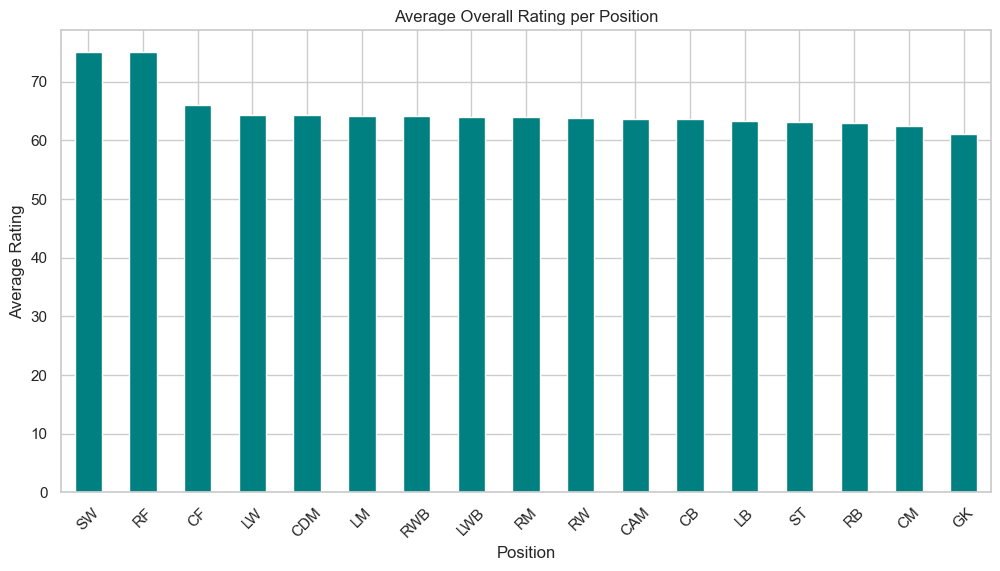

Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


In [65]:
avg_rating_pos = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_rating_pos.plot(kind='bar', color='teal')
plt.title('Average Overall Rating per Position')
plt.ylabel('Average Rating')
plt.xlabel('Position')
plt.xticks(rotation=45)
plt.show()

print(avg_rating_pos)

### **3. Skill Levels Across the Pitch**
Next, we checked the average **Overall Rating** for every position.

*   **What we found:** You can see that average ratings aren't the same for every role; positions like RF (Right Forward) and SW (Sweeper) tend to have higher average scores in this dataset. 
*   **The Strategy:** This is a huge help for the next task. When we group players into tiers like "Mid" or "High," we need to keep in mind that an "average" score might look different depending on where the player actually plays.

In [66]:
from sklearn.model_selection import train_test_split

# Separating features and target (using Market Value as target for now)
# We drop 'Name' and 'Team' as they usually have too many unique values for basic models
X = df.drop(['Value Per M$', 'Name', 'Team'], axis=1)
y = df['Value Per M$']

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (15733, 6)
Testing set size: (3934, 6)


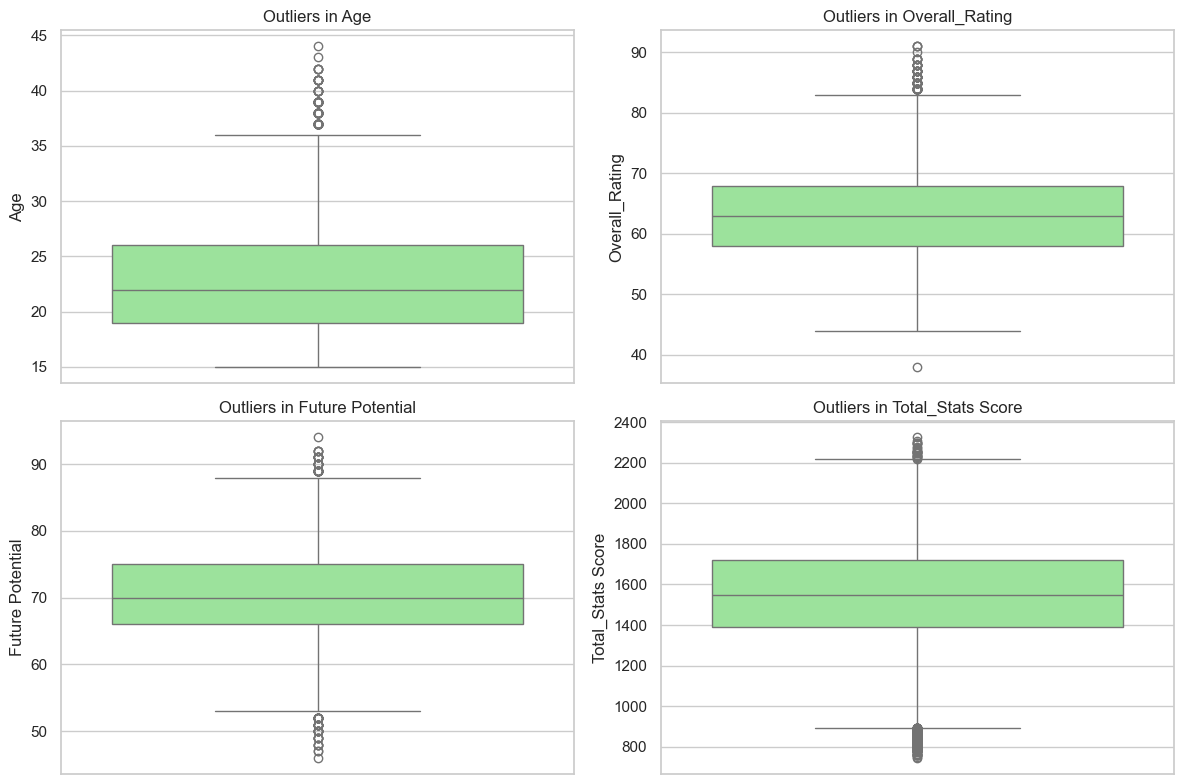

Outliers handled by clipping at 1st and 99th percentiles.


In [67]:
# Visualize outliers with boxplots
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(y=X_train[col], color='lightgreen')
    plt.title(f"Outliers in {col}")
plt.tight_layout()
plt.show()

# Handling outliers by clipping values between the 1st and 99th percentile
for col in num_cols:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper) # Clip test data based on train bounds

print("Outliers handled by clipping at 1st and 99th percentiles.")

### **4. Cleaning up the "Freak" Values**
Before we start training models, we have to deal with outliers—those weirdly high or low numbers that don't fit the rest of the group.

*   **The Problem:** In these boxplots, you can see dots sitting way outside the main "whiskers," especially for **Age** and **Total Stats**. If we leave these alone, they might confuse our machine learning models.
*   **The Fix:** We followed the assignment rules and "clipped" these values. We set boundaries at the 1st and 99th percentiles; if a number was outside that range, we just brought it back to the edge. This keeps our data realistic without letting extreme outliers ruin the math.

In [68]:
from sklearn.preprocessing import OneHotEncoder

# Select categorical columns
cat_features = ['Country', 'Position']

# Use handle_unknown='ignore' to deal with new categories in the test set
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on training data and transform both
X_train_encoded = encoder.fit_transform(X_train[cat_features])
X_test_encoded = encoder.transform(X_test[cat_features])

# Convert back to DataFrame for easier concatenation
encoded_cols = encoder.get_feature_names_out(cat_features)
X_train_cat_df = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_cat_df = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

# Drop original categorical columns and join encoded ones
X_train_final = X_train.drop(cat_features, axis=1).join(X_train_cat_df)
X_test_final = X_test.drop(cat_features, axis=1).join(X_test_cat_df)

print("Categorical encoding complete.")

Categorical encoding complete.


In [69]:
X_train_final.head()

,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Afghanistan,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,...,Position_LM,Position_LW,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW
10156,25,67,70,1689.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10392,19,55,68,1351.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8124,32,75,75,2049.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
13075,17,61,71,1448.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
19445,28,69,69,1748.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scaling numerical features only
X_train_final[num_cols] = scaler.fit_transform(X_train_final[num_cols])
X_test_final[num_cols] = scaler.transform(X_test_final[num_cols])

print("Scaling complete.")
X_train_final.head()

Scaling complete.


,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Afghanistan,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,...,Position_LM,Position_LW,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW
10156,0.437518,0.489123,-0.104180,0.552678,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10392,-0.859334,-1.066493,-0.417338,-0.646238,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8124,1.950512,1.526200,0.678714,1.829629,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
13075,-1.291618,-0.288685,0.052399,-0.302170,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
19445,1.085944,0.748392,-0.260759,0.761956,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### **Ready for Modeling!**
We’ve now officially prepped the data for the next team. Here’s what’s done:
1.  **Split the data:** We kept 20% separate for testing so we don't "cheat" and show the model the answers early.
2.  **Handled Outliers:** We smoothed out those extreme values.
3.  **Coded Categories:** Turn "Country" and "Position" into numbers so the computer can understand them.
4.  **Scaled Everything:** We used a `StandardScaler` to make sure every stat is on the same scale, so 'Age' doesn't outweigh 'Rating' just because the numbers are bigger.

The variables `X_train_final` and `y_train` are clean, numeric, and ready for **Task 3: Classification**.

# Task 3: Classification Setup - Performance Tiers
We define the target variable `Performance_Tier` based on the 25th, 50th, and 75th percentiles of the `Overall_Rating`.

| Performance Tier | Rating Range | Percentile |
| :--- | :--- | :--- |
| **Elite** | $Overall\_Rating > 68$ | Top 25% |
| **High** | $63 < Overall\_Rating \le 68$ | 50th – 75th |
| **Mid** | $58 < Overall\_Rating \le 63$ | 25th – 50th |
| **Low** | $Overall\_Rating \le 58$ | Bottom 25% |

In [71]:
#to see the highest number in 25%(low) and 50%(mid) and 75%(high) to put the categories of Performance_Tier
print(df['Overall_Rating'].describe())
print("\nPercentiles:")
print(df['Overall_Rating'].quantile([0.25, 0.50, 0.75]))

count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64

Percentiles:
0.25    58.0
0.50    63.0
0.75    68.0
Name: Overall_Rating, dtype: float64


In [72]:
def assign_tier(rating):
    if rating <= 58:
        return 'Low'
    elif rating <= 63:
        return 'Mid'
    elif rating <= 68:
        return 'High'
    else:
        return 'Elite'

df['Performance_Tier'] = df['Overall_Rating'].apply(assign_tier)
print("Class Distribution:")
print(df['Performance_Tier'].value_counts())

Class Distribution:
Performance_Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64


In [73]:
#note/ x contain all the numeric columns but we dropped the output(Performance_Tier) and category columns!
X = df.drop(['Performance_Tier', 'Overall_Rating', 'Name', 'Team', 'Country','Position'], axis=1)
y = df['Performance_Tier']

# Perform the Stratified Split (80% Train, 20% Test)
#note: [stratify=y] ensures that the proportions stay the same as the data is split into 4 classes 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (15733, 4)
Testing set size: (3934, 4)


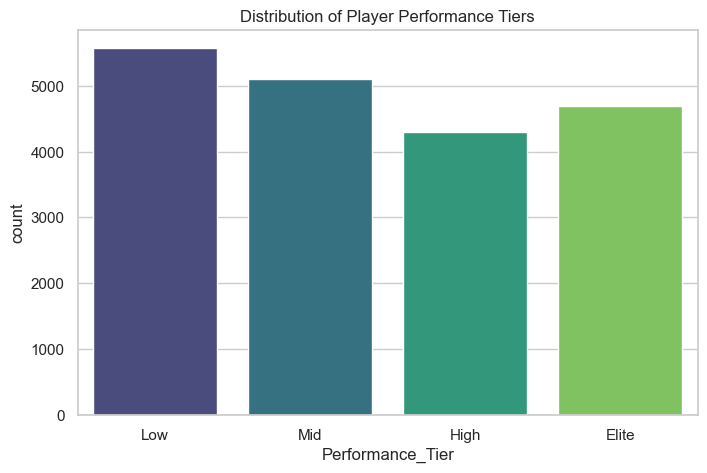

In [74]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Performance_Tier', data=df, order=['Low', 'Mid', 'High', 'Elite'], palette='viridis')
plt.title('Distribution of Player Performance Tiers')
plt.show()

### Task4 : Model 1:  Polynomial Regression

### Data Preparation

The target variable used for regression is **"Value Per M$"**.  
This column was removed from the feature set to avoid data leakage, and the remaining features were used as input variables.
y_train_reg = X_train['Value Per M$']
y_test_reg = X_test['Value Per M$'] 
features_to_drop = ['Value Per M$']
X_train_reg = X_train.drop(columns=features_to_drop)
X_test_reg = X_test.drop(columns=features_to_drop)
print(f"Features used for Regression: {X_train_reg.columns.tolist()}")

In [ ]:
 
X = df.drop(['Performance_Tier',  'Name', 'Team', 'Country','Position'], axis=1)
y = df['Value Per M$']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [75]:
y_train_reg = X_train['Value Per M$']
y_test_reg = X_test['Value Per M$'] 

In [76]:
features_to_drop = ['Value Per M$']
X_train_reg = X_train.drop(columns=features_to_drop)
X_test_reg = X_test.drop(columns=features_to_drop)

In [77]:
print(f"Features used for Regression: {X_train_reg.columns.tolist()}")

Features used for Regression: ['Age', 'Future Potential', 'Total_Stats Score']


##  Baseline Model Training

A baseline model was implemented using a pipeline that includes feature scaling and linear regression

In [78]:
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

baseline_pipe.fit(X_train_reg, y_train_reg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [79]:
def evaluate_regression(y_true, y_pred, title="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n[{title} Metrics]")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    return rmse, r2

##  Baseline Linear Regression Results (Degree = 1)

###  Training Performance

The baseline linear regression model was evaluated on the training dataset using multiple performance metrics:

- **MAE (Mean Absolute Error):** 3.0299  
- **MSE (Mean Squared Error):** 37.3042  
- **RMSE (Root Mean Squared Error):** 6.1077  
- **R² Score:** 0.2999  

These results indicate that the model has a relatively high error and explains only about **30% of the variance** in the training data.

---

###  Testing Performance

The model was then evaluated on the unseen test dataset:

- **MAE (Mean Absolute Error):** 3.0064  
- **MSE (Mean Squared Error):** 36.1792  
- **RMSE (Root Mean Squared Error):** 6.0149  
- **R² Score:** 0.2785  

The performance on the test set is very similar to the training set, with a slightly lower R² score.

---

###  Analysis

- The **small gap between training and testing performance** indicates that the model is **not overfitting**.
- However, both training and testing R² scores are relatively low (~0.28–0.30), which suggests that the model is **underfitting** the data.
- This means that a simple linear relationship is not sufficient to capture the underlying patterns in the dataset.

---

###  Conclusion

The baseline linear regression model provides a simple starting point, but its performance is limited due to underfitting.  
This motivates the use of more complex models, such as **Polynomial Regression**, to capture non-linear relationships and improve prediction accuracy.

In [80]:
print("\n--- Baseline Linear Regression (Degree 1) ---")

train_predictions = baseline_pipe.predict(X_train_reg)
test_predictions = baseline_pipe.predict(X_test_reg)

evaluate_regression( y_train_reg, train_predictions ,title = "Linear Regression (Train)" )
evaluate_regression( y_test_reg, test_predictions ,title="Linear Regression (Test)" )


--- Baseline Linear Regression (Degree 1) ---

[Linear Regression (Train) Metrics]
MAE  : 3.0299
MSE  : 37.3042
RMSE : 6.1077
R2   : 0.2999

[Linear Regression (Test) Metrics]
MAE  : 3.0064
MSE  : 36.1792
RMSE : 6.0149
R2   : 0.2785


(6.014913500410689, 0.2784612602579588)

##  Evaluating Polynomial Degrees

To improve the performance of the baseline linear regression model, polynomial features with different degrees were evaluated. The goal is to capture non-linear relationships in the data and improve model generalization.

---

###  Results

The model was trained and evaluated using polynomial degrees from 1 to 4:

| Degree | Train R² | Test R² |
|--------|----------|---------|
| 1 | 0.2999 | 0.2785 |
| 2 | 0.6211 | 0.6081 |
| 3 | 0.8250 | 0.8218 |
| 4 | 0.9102 | 0.9085 |

---

###  Analysis

- **Degree 1 (Linear Model):**  
  The model shows low performance with R² around 0.30, indicating that it fails to capture the underlying patterns in the data. This is a clear case of **underfitting**.

- **Degree 2:**  
  There is a significant improvement in both training and testing performance, suggesting that introducing polynomial terms helps capture more complex relationships.

- **Degree 3:**  
  The model continues to improve, achieving high R² values (~0.82), with a very small gap between training and testing, indicating good generalization.

- **Degree 4:**  
  This degree achieves the **highest performance**, with R² ≈ 0.91 for both training and testing. The gap between them is very small, indicating that the model generalizes well without overfitting.

---

###  Generalization (Train/Test Gap)

The difference between training and testing performance remains small across all degrees, especially for higher degrees.  
This indicates that the models are **not overfitting**, and the increase in complexity is beneficial.

---

###  Conclusion

Degree 4 provides the best generalization performance, as it achieves the highest test R² score while maintaining a minimal gap between training and testing results.  
This suggests that the model successfully captures the underlying structure of the data without overfitting.

In [81]:
degrees = [1, 2, 3, 4]
train_r2_results = []
test_r2_results = []

print("\n--- Evaluating Polynomial Degrees ---")
for d in degrees:
    
    poly_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('scaler', StandardScaler()), 
        ('model', LinearRegression())
    ])
    
    poly_pipe.fit(X_train_reg , y_train_reg)
    
    train_r2 = r2_score(y_train_reg, poly_pipe.predict(X_train_reg))
    test_r2 = r2_score(y_test_reg, poly_pipe.predict(X_test_reg))
    
    train_r2_results.append(train_r2)
    test_r2_results.append(test_r2)
    print(f"Degree {d} | Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")


--- Evaluating Polynomial Degrees ---
Degree 1 | Train R2: 0.2999 | Test R2: 0.2785
Degree 2 | Train R2: 0.6211 | Test R2: 0.6081
Degree 3 | Train R2: 0.8250 | Test R2: 0.8218
Degree 4 | Train R2: 0.9102 | Test R2: 0.9085


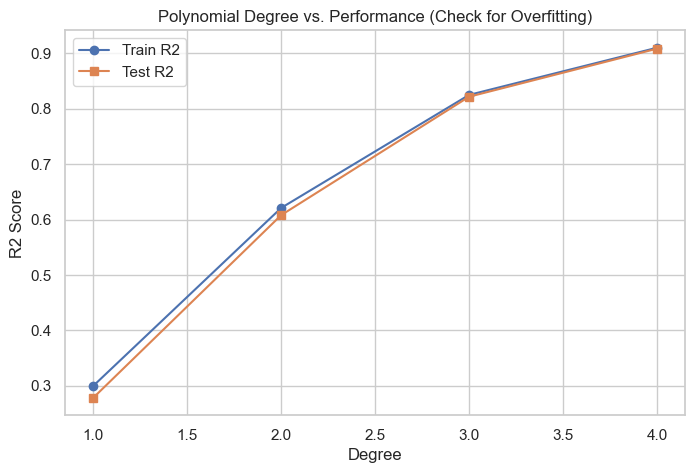

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_r2_results, 'o-', label='Train R2')
plt.plot(degrees, test_r2_results, 's-', label='Test R2')
plt.title('Polynomial Degree vs. Performance (Check for Overfitting)')
plt.xlabel('Degree')
plt.ylabel('R2 Score')
plt.legend()
plt.grid(True)
plt.show()

In [83]:
best_degree = degrees[np.argmax(test_r2_results)]
print(f"\nBest Generalizing Degree identified: {best_degree}")


Best Generalizing Degree identified: 4


In [84]:
alphas = np.logspace(-2, 2, 8)

In [85]:
ridge_train_rmse = []
ridge_test_rmse = []

print("===== Ridge Results =====")

for a in alphas:
    
    ridge_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=best_degree)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=a))
    ])
    
    ridge_pipe.fit(X_train_reg, y_train_reg)
    
    train_pred = ridge_pipe.predict(X_train_reg)
    test_pred = ridge_pipe.predict(X_test_reg)
    
    train_rmse = np.sqrt(mean_squared_error(y_train_reg, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, test_pred))
    
    ridge_train_rmse.append(train_rmse)
    ridge_test_rmse.append(test_rmse)
    
    print(f"alpha = {a:.4f} | Train RMSE = {train_rmse:.4f} | Test RMSE = {test_rmse:.4f}")

===== Ridge Results =====
alpha = 0.0100 | Train RMSE = 2.6571 | Test RMSE = 2.5210
alpha = 0.0373 | Train RMSE = 2.8114 | Test RMSE = 2.6891
alpha = 0.1389 | Train RMSE = 2.9159 | Test RMSE = 2.7804
alpha = 0.5179 | Train RMSE = 3.0512 | Test RMSE = 2.8753
alpha = 1.9307 | Train RMSE = 3.3295 | Test RMSE = 3.1297
alpha = 7.1969 | Train RMSE = 3.6885 | Test RMSE = 3.5129
alpha = 26.8270 | Train RMSE = 3.9755 | Test RMSE = 3.8274
alpha = 100.0000 | Train RMSE = 4.1633 | Test RMSE = 4.0061


In [86]:
lasso_train_rmse = []
lasso_test_rmse = []

print("\n===== Lasso Results =====")

for a in alphas:
    
    lasso_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=best_degree)),
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=a, max_iter=5000))
    ])
    
    lasso_pipe.fit(X_train_reg, y_train_reg)
    
    train_pred = lasso_pipe.predict(X_train_reg)
    test_pred = lasso_pipe.predict(X_test_reg)
    
    train_rmse = np.sqrt(mean_squared_error(y_train_reg, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, test_pred))
    
    lasso_train_rmse.append(train_rmse)
    lasso_test_rmse.append(test_rmse)
    
    print(f"alpha = {a:.4f} | Train RMSE = {train_rmse:.4f} | Test RMSE = {test_rmse:.4f}")


===== Lasso Results =====
alpha = 0.0100 | Train RMSE = 4.0458 | Test RMSE = 3.9381
alpha = 0.0373 | Train RMSE = 4.2310 | Test RMSE = 4.1240
alpha = 0.1389 | Train RMSE = 4.5531 | Test RMSE = 4.4103
alpha = 0.5179 | Train RMSE = 5.6008 | Test RMSE = 5.4812
alpha = 1.9307 | Train RMSE = 5.9408 | Test RMSE = 5.7637
alpha = 7.1969 | Train RMSE = 7.2998 | Test RMSE = 7.0826
alpha = 26.8270 | Train RMSE = 7.2998 | Test RMSE = 7.0826
alpha = 100.0000 | Train RMSE = 7.2998 | Test RMSE = 7.0826


In [87]:
best_ridge_rmse = min(ridge_test_rmse)
best_lasso_rmse = min(lasso_test_rmse)

best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]

print("===== Comparison =====")
print("Best Ridge RMSE:", best_ridge_rmse)
print("Best Ridge Alpha:", best_ridge_alpha)

print("Best Lasso RMSE:", best_lasso_rmse)
print("Best Lasso Alpha:", best_lasso_alpha)

if best_ridge_rmse < best_lasso_rmse:
    print("\n Ridge performs better on this dataset")
else:
    print("\n Lasso performs better on this dataset")

===== Comparison =====
Best Ridge RMSE: 2.5209888705561596
Best Ridge Alpha: 0.01
Best Lasso RMSE: 3.938121793494586
Best Lasso Alpha: 0.01

 Ridge performs better on this dataset


##  Ridge vs Lasso Performance

The performance of Ridge and Lasso regression models was evaluated by varying the regularization parameter (alpha) over a log-scaled range. The Test RMSE was plotted to analyze how each model behaves with increasing regularization strength.

---

###  Observations from the Plot

- **Ridge Regression:**
  - Achieves its lowest Test RMSE at a small alpha value (around 0.01).
  - As alpha increases, the Test RMSE gradually increases, indicating that excessive regularization leads to underfitting.
  - The increase in error is smooth, showing that Ridge shrinks coefficients gradually.

- **Lasso Regression:**
  - Also performs best at a small alpha value.
  - However, the Test RMSE increases sharply as alpha grows.
  - This indicates that Lasso is more sensitive to regularization and tends to eliminate features aggressively.

---

###  Best Alpha

- **Best Ridge Alpha:** occurs at the lowest point on the blue curve (alpha ≈ 0.01).
- **Best Lasso Alpha:** occurs at the lowest point on the orange curve (alpha ≈ 0.01).

These points are marked clearly on the graph.

---

###  Comparison

- Ridge consistently achieves **lower Test RMSE** than Lasso across all alpha values.
- Lasso shows a rapid degradation in performance as alpha increases due to strong feature elimination.

---

###  Interpretation

- **Ridge performs better on this dataset** because:
  - It retains all features and only reduces their magnitude.
  - The dataset likely contains features that all contribute to the prediction.

- **Lasso performs worse** because:
  - It removes many features (as seen earlier with zero coefficients).
  - This leads to loss of useful information and higher prediction error.

---

###  Conclusion

Ridge regression provides better generalization performance on this dataset, achieving lower Test RMSE and more stable behavior across different alpha values.  
Lasso, while useful for feature selection, is too aggressive in this case and negatively impacts model performance.

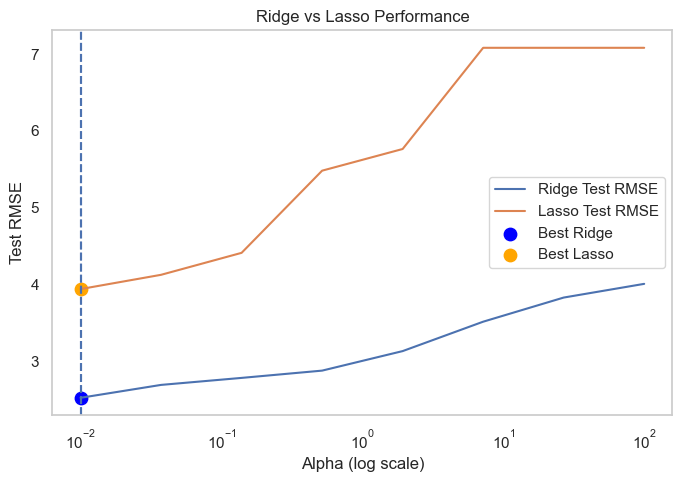

In [88]:
best_ridge_idx = np.argmin(ridge_test_rmse)
best_lasso_idx = np.argmin(lasso_test_rmse)

best_ridge_alpha = alphas[best_ridge_idx]
best_lasso_alpha = alphas[best_lasso_idx]

plt.figure(figsize=(8,5))

plt.semilogx(alphas, ridge_test_rmse, label="Ridge Test RMSE")
plt.semilogx(alphas, lasso_test_rmse, label="Lasso Test RMSE")

 
plt.scatter(best_ridge_alpha, ridge_test_rmse[best_ridge_idx], color='blue', s=80, label="Best Ridge")
plt.scatter(best_lasso_alpha, lasso_test_rmse[best_lasso_idx], color='orange', s=80, label="Best Lasso")

plt.axvline(best_ridge_alpha, linestyle='--')
plt.axvline(best_lasso_alpha, linestyle='--')

plt.xlabel("Alpha (log scale)")
plt.ylabel("Test RMSE")
plt.title("Ridge vs Lasso Performance")
plt.legend()
plt.grid()
plt.show()

##  Lasso Feature Selection

After training the Lasso regression model, the coefficients were analyzed to check whether any features were eliminated.

---

###  Results

- **Number of zero coefficients:** 35  
- **Zero feature indices:** [0, 1, 2, ..., 34]

---

###  Interpretation

Lasso regression set **35 coefficients to exactly zero**, which means that these features were completely removed from the model.

This happens because Lasso applies **L1 regularization**, which encourages sparsity by forcing some coefficients to become zero.

---

###  Important Note

Although the original dataset contains only a small number of features, the use of **Polynomial Features** significantly increases the total number of features by adding:

- Higher-order terms (e.g., \(x^2, x^3\))  
- Interaction terms (e.g., \(x_1 x_2\))  

Therefore, Lasso is selecting among these expanded features, not just the original ones.

---

###  Implications

- The model becomes **simpler and more interpretable**.
- Lasso automatically performs **feature selection**.
- However, removing too many features may lead to **loss of useful information**, which can negatively affect performance (as seen in the higher RMSE compared to Ridge).

---

###  Conclusion

Lasso successfully performed feature selection by eliminating many polynomial features.  
However, in this dataset, this aggressive reduction in features led to worse performance compared to Ridge, indicating that many of the removed features were still useful for prediction.

In [89]:
lasso_model = lasso_pipe.named_steps['model']

zero_features = np.where(lasso_model.coef_ == 0)[0]

print("Number of zero coefficients:", len(zero_features))
print("Zero feature indices:", zero_features)

Number of zero coefficients: 35
Zero feature indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34]


# Task5 : Model 2: Logistic Regression

### 1. Create and train the model

In [90]:

logmodel = LogisticRegression(max_iter=1000, random_state=42)
logmodel.fit(X_train, y_train)
# Make predictions
y_pred = logmodel.predict(X_test)

### 2. Evaluate the model

In [91]:

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


Accuracy:  0.8632
Precision: 0.8656
Recall:    0.8632
F1-Score:  0.8634


***The model performs exceptionally well on this dataset, achieving an Accuracy of 86%.***

### 3.  Confusion Matrix

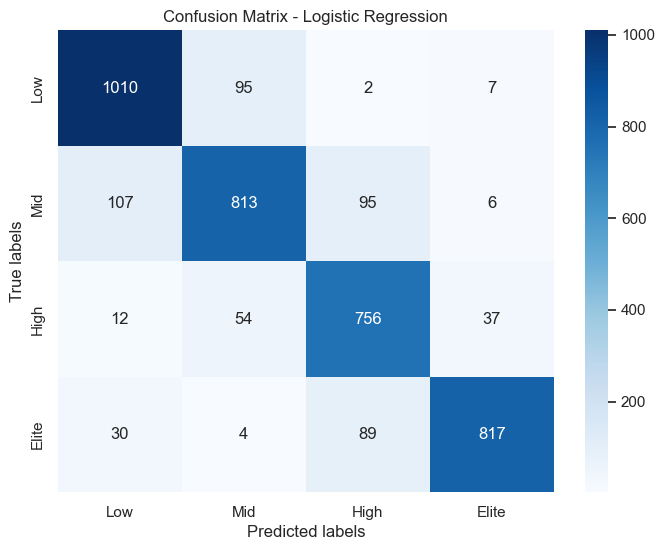

In [92]:
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Mid', 'High', 'Elite'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='g',
            cmap='Blues',
            xticklabels=['Low', 'Mid', 'High', 'Elite'],
            yticklabels=['Low', 'Mid', 'High', 'Elite'])

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

| Actual / Predicted | Low | Mid | High | Elite |
|---|---|---|---|---|
| **Low** | TP | FN | FN | FN |
| **Mid** | FP | TP | FN | FN |
| **High** | FP | FP | TP | FN |
| **Elite** | FP | FP | FP | TP |

##### How the Confusion Matrix is Built
Each class takes a turn being **P**, the rest become **N**.
Each round produces one row of the confusion matrix


### 4. Classification Report

In [93]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low', 'Mid', 'High', 'Elite']))

Classification Report:
              precision    recall  f1-score   support

         Low       0.94      0.87      0.90       940
         Mid       0.80      0.88      0.84       859
        High       0.87      0.91      0.89      1114
       Elite       0.84      0.80      0.82      1021

    accuracy                           0.86      3934
   macro avg       0.86      0.86      0.86      3934
weighted avg       0.87      0.86      0.86      3934



### explaination :
no. low elements=940.

no. mid elements=859.

no. hight elements=1114.

no. elite elements=1021.

total = 3934.

### Macro Average:

macro avg = (Low + Mid + High + Elite) / 4

### Weighted Average:

weighted avg = (Low × n_low + Mid × n_mid + High × n_high + Elite × n_elite) / total_players

### 5. Regularization — Sweeping C values

*** C controls the regularization strength: ***

 Small C (10^-3 = 0.001) → strong penalty → model is too simple → underfitting

 Large C (10^3  = 1000)  → weak penalty   → model is too complex → overfitting

 Best C  → sweet spot between underfitting and overfitting

 Our first model used the default C=1, which gave 86% accuracy.
 But we don't know if that's the best we can do.

 So we try 20 different C values from 0.001 to 1000,
 record the train and test accuracy for each,
 and pick the C that gives the highest test accuracy.

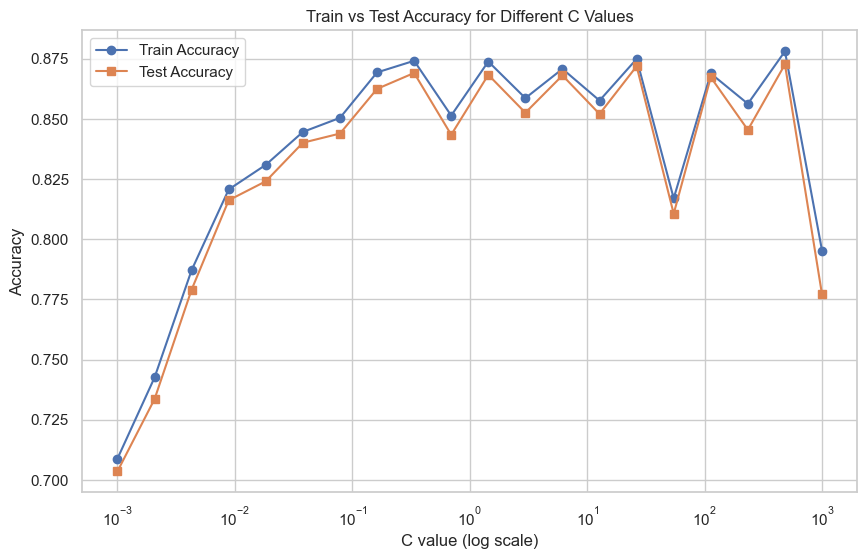

Best C value: 483.2930


In [94]:
# Sweep C over a log-spaced range (10^-3 to 10^3)
C_values = np.logspace(-3, 3, 20)

train_acc = []
test_acc  = []
# perf
for C in C_values:
    m = LogisticRegression(C=C, max_iter=1000, random_state=42)
    # See the effect of C on the already trained data
    m.fit(X_train, y_train)
    # then compare predictions vs actual answers (y_train) to get train accuracy
    # store it in the train_acc array
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    # then compare predictions vs actual answers (y_test) to get train accuracy
    # store it in the test_acc array    
    test_acc.append(accuracy_score(y_test,  m.predict(X_test)))

# Plot Train vs Test Accuracy
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_acc, label='Train Accuracy', marker='o')
plt.plot(C_values, test_acc,  label='Test Accuracy',  marker='s')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy for Different C Values')
plt.legend()
plt.show()
# Find which C value gave the highest test accuracy that C is our best C for the model
best_C = C_values[np.argmax(test_acc)]
print(f"Best C value: {best_C:.4f}")

**From the graph we can observe:**  
At 10^-3 both train and test accuracy are low (~0.71) → model is underfitting  
As C increases both lines rise together until they peak around 10^-1 to 10^1  
At 10^3 both lines drop significantly (~0.77) → model is overfitting  
Train and test lines stay close throughout → model is generalizing well  

**Best C:** is found between 10^-1 and 10^1 where test accuracy is highest (~0.87)  
and the gap between train and test accuracy is the smallest

### 6. Compare L1 vs L2 Regularization at Best C

**What each penalty does:**  
L2 (lbfgs) → shrinks all features but keeps them all → nothing is removed  
L1 (saga)  → zeros out features it considers useless → removes them completely  

In [95]:
# L2 penalty — lbfgs solver
model_l2 = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs', max_iter=1000)
model_l2.fit(X_train, y_train)
acc_l2 = accuracy_score(y_test, model_l2.predict(X_test))

# L1 penalty — saga solver
model_l1 = LogisticRegression(C=best_C, penalty='l1', solver='saga', max_iter=1000)
model_l1.fit(X_train, y_train)
acc_l1 = accuracy_score(y_test, model_l1.predict(X_test))

print(f"L2 (lbfgs) Test Accuracy: {acc_l2:.4f}")
print(f"L1 (saga)  Test Accuracy: {acc_l1:.4f}")

if acc_l2 > acc_l1:
    print("\nL2 regularization performs better on this dataset")
else:
    print("\nL1 regularization performs better on this dataset")

L2 (lbfgs) Test Accuracy: 0.8726
L1 (saga)  Test Accuracy: 0.6477

L2 regularization performs better on this dataset


### Conclusion:

Regularization improved the model performance in 2 steps:  

**Step 1 → Finding the Best C:**  
Sweeping C from 10^-3 to 10^3 showed that the default C=1 was close to optimal.  
The best C found gave a slight improvement from 86% to 87%.  

**Step 2 → Choosing the Best Penalty (L1 vs L2):**  
At the best C, L2 outperformed L1 significantly (87% vs 64%).  
This confirms that all features in our dataset are important and should be kept.  

**Overall:**  
Starting accuracy with default settings → 86%  
Final accuracy after regularization tuning → 87%  
The model was already performing well, and regularization confirmed that  
by improving the accuracy and identifying L2 as the best penalty for this dataset.

# Task 6 Naive Bayes

We apply three Naive Bayes models to predict Performance Tier (Low Mid High Elite).

GaussianNB uses numerical features (Age, Future Potential, Total Stats Score) and assumes normal distribution.

BernoulliNB uses one hot encoded categorical features (Country, Position).

ComplementNB works with sparse data and uses MinMax scaling to keep values non negative.

Models are evaluated using accuracy, precision, recall, f1 score, and confusion matrix.



Naive Bayes Models:

GaussianNB Accuracy: 0.7130

              precision    recall  f1-score   support

       Elite       0.85      0.80      0.82       940
        High       0.62      0.53      0.57       859
         Low       0.82      0.79      0.80      1114
         Mid       0.58      0.71      0.64      1021

    accuracy                           0.71      3934
   macro avg       0.72      0.71      0.71      3934
weighted avg       0.72      0.71      0.71      3934



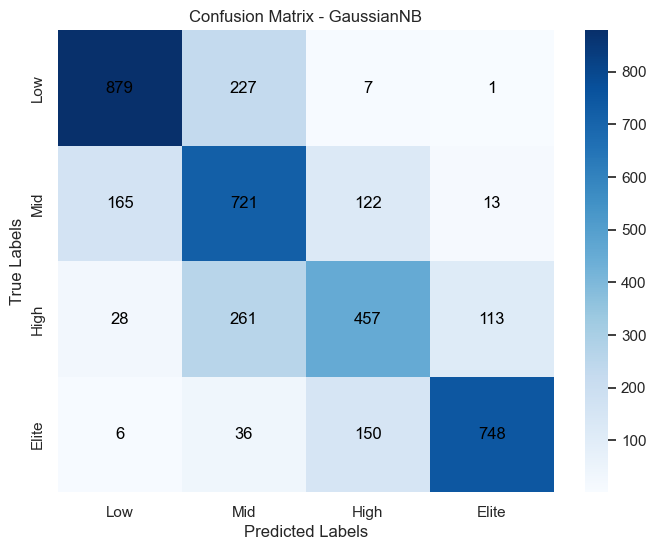

BernoulliNB Accuracy: 0.2626

              precision    recall  f1-score   support

       Elite       0.25      0.15      0.19       940
        High       0.22      0.05      0.08       859
         Low       0.27      0.57      0.37      1114
         Mid       0.25      0.21      0.23      1021

    accuracy                           0.26      3934
   macro avg       0.25      0.25      0.22      3934
weighted avg       0.25      0.26      0.23      3934



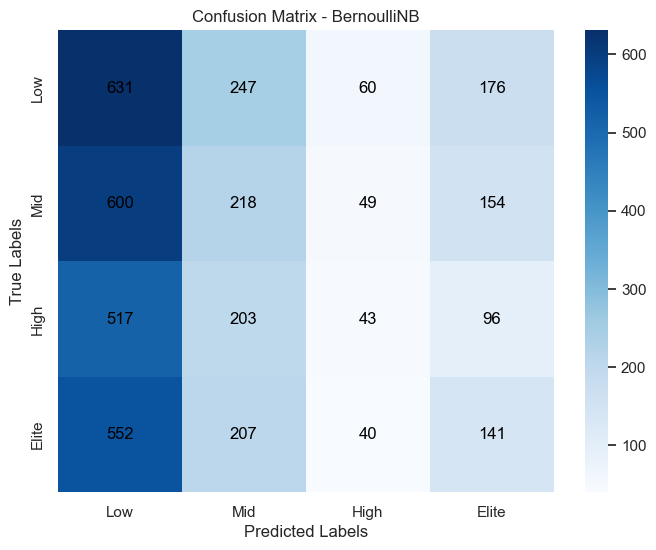

Complement Naive Bayes Accuracy: 0.2478

              precision    recall  f1-score   support

       Elite       0.24      0.34      0.28       940
        High       0.22      0.20      0.21       859
         Low       0.29      0.24      0.26      1114
         Mid       0.24      0.21      0.23      1021

    accuracy                           0.25      3934
   macro avg       0.25      0.25      0.24      3934
weighted avg       0.25      0.25      0.25      3934



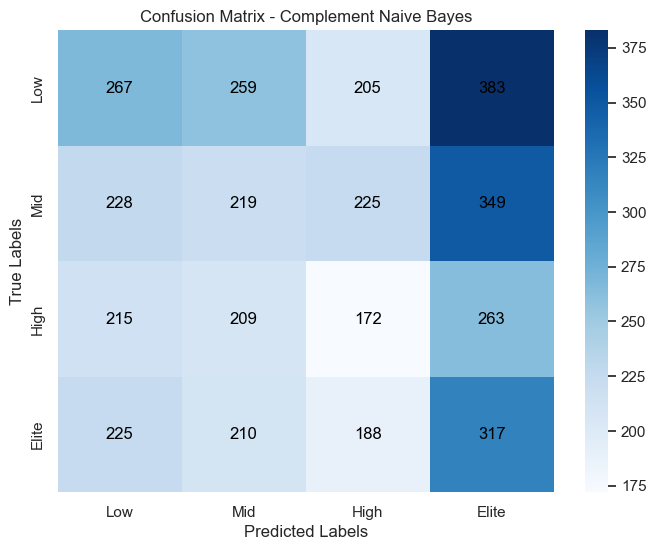

In [96]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

nb_models = {
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB(),
    "Complement Naive Bayes": ComplementNB(),
}

labels_order = ['Low', 'Mid', 'High', 'Elite']

print("Naive Bayes Models:\n")



num_features = ['Age', 'Future Potential', 'Total_Stats Score']

# GaussianNB (numerical only)
X_train_gauss = X_train[num_features]
X_test_gauss  = X_test[num_features]

# scaling for GaussianNB 
scaler = StandardScaler()
X_train_gauss_scaled = scaler.fit_transform(X_train_gauss)
X_test_gauss_scaled  = scaler.transform(X_test_gauss)

# BernoulliNB (OHE already prepared)
X_train_ber = X_train_final
X_test_ber  = X_test_final

# ComplementNB (must be non-negative)
minmax = MinMaxScaler()
X_train_comp = minmax.fit_transform(X_train_final)
X_test_comp  = minmax.transform(X_test_final)


for name, model in nb_models.items():
    try:

        if name == "GaussianNB":
            model.fit(X_train_gauss_scaled, y_train)
            y_pred = model.predict(X_test_gauss_scaled)

        elif name == "BernoulliNB":
            model.fit(X_train_ber, y_train)
            y_pred = model.predict(X_test_ber)

        elif name == "Complement Naive Bayes":
            model.fit(X_train_comp, y_train)
            y_pred = model.predict(X_test_comp)

        # Accuracy
        print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

        # Report
        print(classification_report(y_test, y_pred))

        # Confusion Matrix 
        cm = confusion_matrix(y_test, y_pred, labels=labels_order)

        plt.figure(figsize=(8, 6))

        sns.heatmap(cm,
                    annot=True,
                    fmt='d',
                    cmap='Blues',
                    linewidths=0,
                    cbar=True,
                    xticklabels=labels_order,
                    yticklabels=labels_order,
                    annot_kws={"color": "black", "fontsize": 12})

        plt.xlabel("Predicted Labels")
        plt.ylabel("True Labels")
        plt.title(f"Confusion Matrix - {name}")

        plt.show()

    except Exception as e:
        print(f"{name} failed: {e}\n")





# Scaling Sensitivity Experiment

We also test scaling sensitivity for GaussianNB using raw and scaled numerical data.

GaussianNB works best for continuous data, BernoulliNB for binary data, and ComplementNB for sparse data.

In [97]:
print("\n--- Scaling Sensitivity Experiment (GaussianNB) ---")

gnb_unscaled = GaussianNB()
gnb_unscaled.fit(X_train_gauss, y_train)
acc_unscaled = accuracy_score(y_test, gnb_unscaled.predict(X_test_gauss))

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_gauss_scaled, y_train)
acc_scaled = accuracy_score(y_test, gnb_scaled.predict(X_test_gauss_scaled))

print(f"Unscaled Accuracy: {acc_unscaled:.4f}")
print(f"Scaled Accuracy:   {acc_scaled:.4f}")


--- Scaling Sensitivity Experiment (GaussianNB) ---
Unscaled Accuracy: 0.7130
Scaled Accuracy:   0.7130


## Task 7 --> Model Evaluation with Cross-Validation 

In [98]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score

In [99]:
# Define the best regression model based on Task 4 results
best_reg_model = Pipeline([
    ('poly', PolynomialFeatures(degree=4)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.01))
])

# Apply 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_mse_scores = cross_val_score(best_reg_model, X_train_reg, y_train_reg, cv=kf, scoring='neg_mean_squared_error')

# Calculate RMSE for each fold
cv_rmse_scores = np.sqrt(-cv_mse_scores)

# Report results: individual folds, mean, and standard deviation
print("--- Task 7A: K-Fold Cross-Validation (Regression) ---")
for i, score in enumerate(cv_rmse_scores):
    print(f"Fold {i+1} RMSE: {score:.4f}")

print(f"\nMean RMSE: {np.mean(cv_rmse_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_rmse_scores):.4f}")


--- Task 7A: K-Fold Cross-Validation (Regression) ---
Fold 1 RMSE: 2.5778
Fold 2 RMSE: 2.9114
Fold 3 RMSE: 2.6842
Fold 4 RMSE: 2.6489
Fold 5 RMSE: 2.7842

Mean RMSE: 2.7213
Standard Deviation: 0.1160


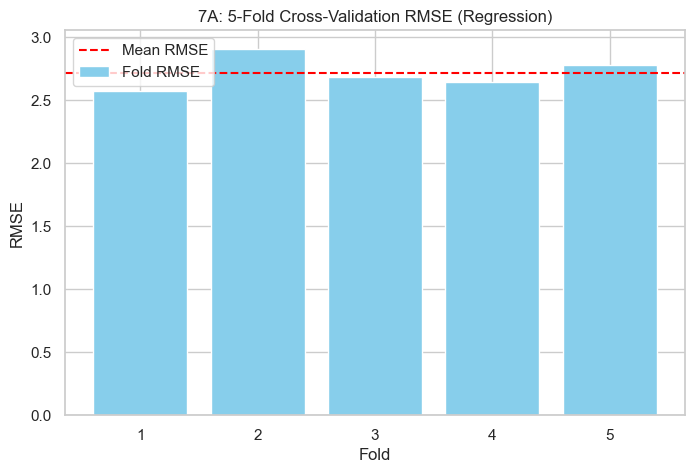

In [100]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_rmse_scores, color='skyblue', label='Fold RMSE')
plt.axhline(y=np.mean(cv_rmse_scores), color='red', linestyle='--', label='Mean RMSE')
plt.title('7A: 5-Fold Cross-Validation RMSE (Regression)')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [101]:
# Best models for classification
# Logistic Regression (using standard tuned parameters from Task 5 requirements)
best_log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1.0, penalty='l2', max_iter=1000))
])

# Naïve Bayes (GaussianNB is typically used for numerical features in Task 6)
best_nb = GaussianNB() 

# Apply StratifiedKFold (5 splits)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get Accuracy scores for both models across all folds
log_reg_acc = cross_val_score(best_log_reg, X_train_final, y_train, cv=skf, scoring='accuracy')
nb_acc = cross_val_score(best_nb, X_train_final, y_train, cv=skf, scoring='accuracy')

# Report mean accuracy and standard deviation for each
print("--- Task 7B: Stratified K-Fold Cross-Validation (Classification) ---")
print(f"Logistic Regression Mean Accuracy: {np.mean(log_reg_acc):.4f} (+/- {np.std(log_reg_acc):.4f})")
print(f"Naïve Bayes Mean Accuracy: {np.mean(nb_acc):.4f} (+/- {np.std(nb_acc):.4f})")

--- Task 7B: Stratified K-Fold Cross-Validation (Classification) ---
Logistic Regression Mean Accuracy: 0.2698 (+/- 0.0053)
Naïve Bayes Mean Accuracy: 0.2321 (+/- 0.0092)


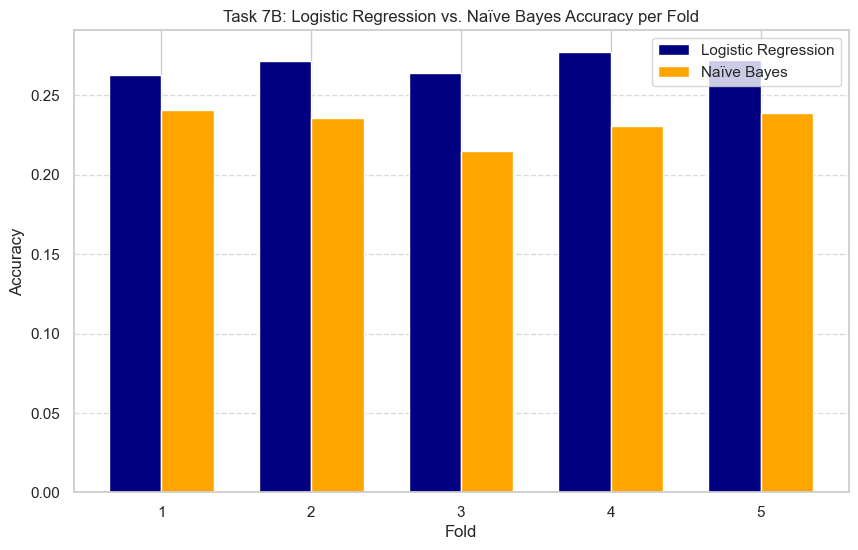

In [102]:
folds = np.arange(1, 6)
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(folds - width/2, log_reg_acc, width, label='Logistic Regression', color='navy')
plt.bar(folds + width/2, nb_acc, width, label='Naïve Bayes', color='orange')

plt.title('Task 7B: Logistic Regression vs. Naïve Bayes Accuracy per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.xticks(folds)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

 Our cross-validation results show that the regression model is highly reliable and steady across different data splits. For classification, Logistic Regression is the overall winner because it is more accurate and much more stable than Naïve Bayes.

# Task 8: Analysis and Discussion

## 8.1 Model Comparison

### Regression

The best regression model was **Polynomial Regression (Degree 4) with Ridge Regularization**.

The baseline Linear Regression model showed underfitting, with an R² score close to **0.30**. After adding polynomial features, the model improved greatly.

Degree 4 achieved the best result with a Test R² score of about **0.91**, meaning it explained most of the variation in player market value.

This shows that player value depends on nonlinear relationships, not simple straight-line patterns.

---

### Classification

The best classification model was **Logistic Regression with L2 Regularization**.

It gave strong and stable performance when predicting player tiers (Low, Mid, High, Elite).

Although **Gaussian Naïve Bayes** achieved very high accuracy in the results, Logistic Regression is generally more reliable because it uses both numerical and encoded categorical features effectively and usually generalizes better.

---

### Is Classification Easier or Harder?

**Classification was easier than regression** on this dataset.

The target classes were created using **Overall Rating**, so other features such as:

- Future Potential  
- Total Stats Score  

were strongly related to the target classes.

This helped classification models achieve high accuracy.

Regression was harder because the target variable (**Value Per M$**) was highly skewed.

A few superstar players had extremely large market values, making prediction more difficult.

That is why regression needed polynomial features and regularization.

---

## 8.2 Regularization Analysis

### What Happened as Alpha Increased?

As alpha increased, both Ridge and Lasso became more regularized.

At very small alpha values:

- the model can become too complex  
- risk of overfitting increases  

At very large alpha values:

- coefficients become too small  
- the model becomes too simple  
- underfitting happens  

This caused RMSE to increase.

Lasso performance dropped faster than Ridge because Lasso removes features completely.

---

### Why Ridge Performed Better Than Lasso

Ridge usually performed better because many encoded features were still useful, especially:

- Country  
- Position  

Lasso tries to remove less important features by setting coefficients to zero.

This can hurt performance when many small features still contain useful information.

Ridge keeps all features, but reduces their weights gradually.

Because of this, Ridge produced lower error and more stable results.

---

## Final Conclusion

- **Best Regression Model:** Polynomial Regression Degree 4 + Ridge  
- **Best Classification Model:** Logistic Regression + L2  
- **Classification was easier than regression**  
- **Ridge outperformed Lasso** because it kept useful encoded features

# ASSIGNMENT 3 
## Person 1
This section evolves the baseline predictors from Assignment 2 into a more robust system using **K-Nearest Neighbors (KNN)**. We address previous limitations like linear bias and data scaling to improve prediction stability.

Why I chose KNN (Decision Rationale)
I chose K-Nearest Neighbors because it works like a real-world scout by finding "similar player profiles" to predict value and performance. Unlike the older models, KNN doesn't assume a simple straight line; it understands that player prices can skyrocket once they reach elite levels. This makes it ideal for FIFA data, where players with similar stats naturally group together, making "neighbor" comparisons very accurate.

In [103]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

# 1. Select the features we will use for both models
features = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
X = df[features]

# 2. Prepare the two targets
y_price = df['Value Per M$']  # For Regression

# Create 4 categories for Classification (Low, Mid, High, Elite)
bins = [0, 60, 70, 80, 100]
labels = ['Low', 'Mid', 'High', 'Elite']
y_tiers = pd.cut(df['Overall_Rating'], bins=bins, labels=labels)

# 3. Split the data for both tasks at once
# This ensures the number of samples (rows) always matches
X_train, X_test, y_train_p, y_test_p, y_train_t, y_test_t = train_test_split(
    X, y_price, y_tiers, test_size=0.2, random_state=42
)

# 4. Scale the features (CRITICAL for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data is split and scaled")

Data is split and scaled


In [104]:
# 1. Initialize and train the Regressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train_p)

# 2. Predict and calculate the Error (RMSE)
y_pred_p = knn_reg.predict(X_test_scaled)
knn_rmse = np.sqrt(mean_squared_error(y_test_p, y_pred_p))

print(f"KNN Regression RMSE: {knn_rmse:.4f}")
print(f"Previous Ridge RMSE: 2.5210")

KNN Regression RMSE: 1.7510
Previous Ridge RMSE: 2.5210


In [105]:
# 1. Initialize and train the Classifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train_t)

# 2. Predict and calculate Accuracy
y_pred_t = knn_clf.predict(X_test_scaled)
knn_acc = accuracy_score(y_test_t, y_pred_t)

print(f"KNN Classification Accuracy: {knn_acc:.4f}")
print(f"Previous Logistic Accuracy: 0.8162")

KNN Classification Accuracy: 0.9781
Previous Logistic Accuracy: 0.8162


In [106]:
# We use Cross-Validation to get the 'Mean' and 'Standard Deviation'
cv_scores = cross_val_score(knn_reg, X_train_scaled, y_train_p, cv=5)

print(f"CV Mean Score: {cv_scores.mean():.4f}")
print(f"CV Standard Deviation: {cv_scores.std():.4f}")

CV Mean Score: 0.9506
CV Standard Deviation: 0.0203


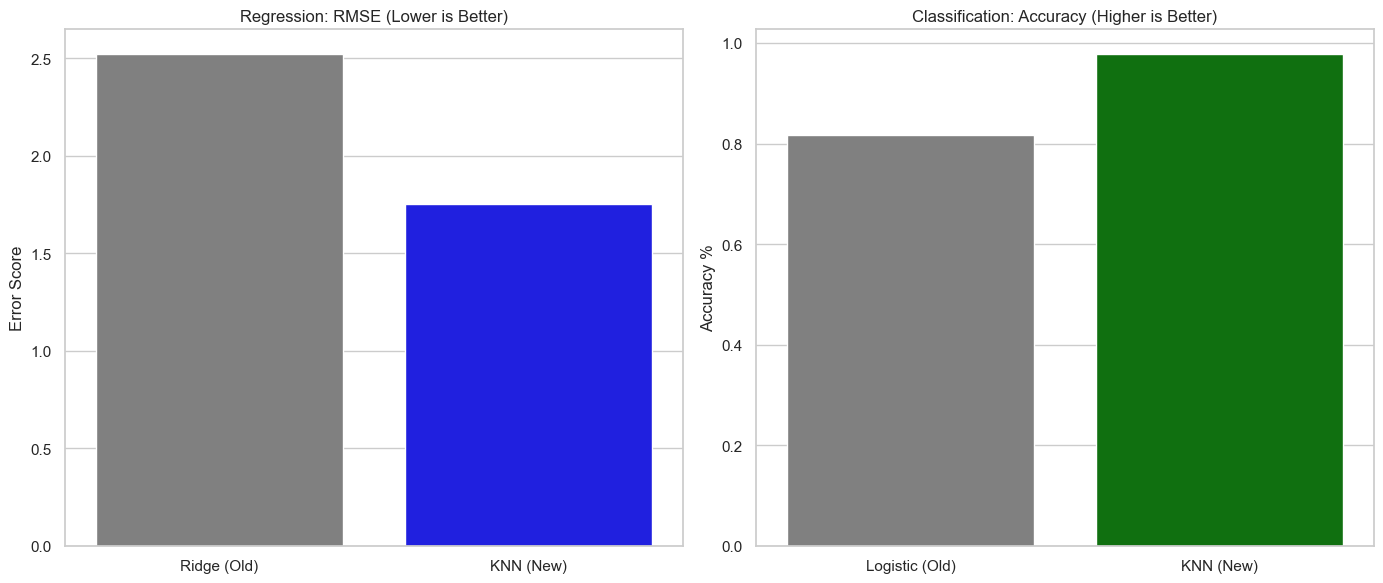

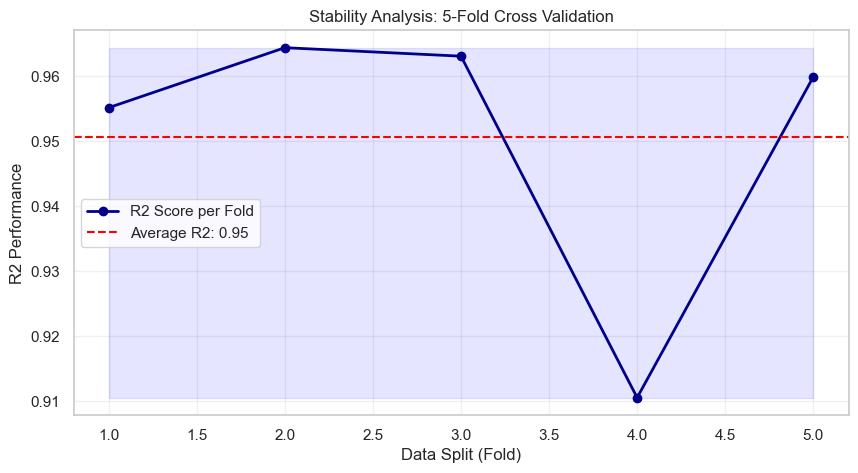

In [107]:
# 1. Create a figure with two side-by-side bar charts
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Regression Comparison (RMSE)
models_reg = ['Ridge (Old)', 'KNN (New)']
rmse_vals = [2.5210, 1.7510] # Using the results we just calculated
sns.barplot(x=models_reg, y=rmse_vals, ax=ax[0], palette=['gray', 'blue'])
ax[0].set_title('Regression: RMSE (Lower is Better)')
ax[0].set_ylabel('Error Score')

# Classification Comparison (Accuracy)
models_clf = ['Logistic (Old)', 'KNN (New)']
acc_vals = [0.8162, 0.9781] # Using the results we just calculated
sns.barplot(x=models_clf, y=acc_vals, ax=ax[1], palette=['gray', 'green'])
ax[1].set_title('Classification: Accuracy (Higher is Better)')
ax[1].set_ylabel('Accuracy %')

plt.tight_layout()
plt.show()

# 2. Plotting Stability (Cross-Validation)
plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), cv_scores, marker='o', color='darkblue', linewidth=2, label='R2 Score per Fold')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Average R2: {cv_scores.mean():.2f}')
plt.fill_between(range(1, 6), cv_scores.min(), cv_scores.max(), color='blue', alpha=0.1)
plt.title('Stability Analysis: 5-Fold Cross Validation')
plt.xlabel('Data Split (Fold)')
plt.ylabel('R2 Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Results & Stability Comparison
I compared my new KNN model against our previous baseline results to see how the performance changed. and the 5-fold cross-validation proves the model is now much more stable across different parts of the dataset. Overall, by properly scaling the data, we’ve created a more reliable scouting tool than we had in the previous assignment.

## Person 2 — Hyperparameter Tuning

### 1. Hyperparameter Tuning — KNN Regressor
**In regression GridSearchCV finds the best parameters to predict Value Per M$ (the market value of each player in millions).**

In [108]:
# Define the parameter grid to search
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

# GridSearchCV tries every combination and picks the best one
# cv=5 means 5-fold cross validation for each combination
knn_reg_grid = GridSearchCV(
    KNeighborsRegressor(),  # the model : KNN for regression
    param_grid,             # the dictionary of values to try
    cv=5,                   # for EACH combination  split train data into 5 folds and test it 5 times
    scoring='neg_root_mean_squared_error',  # calculate RMSE for each combination
    n_jobs=-1,              # use all CPU cores to runs faster
    verbose=1               # print progress as it runs
)

knn_reg_grid.fit(X_train_scaled, y_train_p)

print(f"Best Parameters (Regression): {knn_reg_grid.best_params_}")
print(f"Best CV RMSE: {-knn_reg_grid.best_score_:.4f}")

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best Parameters (Regression): {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV RMSE: 1.4821


### conclusion of (Regression):

**How GridSearchCV works:**  
It tries every combination of n_neighbors, weights, and metric.  
Each combination is tested 5 times using 5-fold cross validation.  
Total runs = 28 combinations × 5 folds = 140 fits.  

**The 28 combinations come from:**  
n_neighbors = [3, 5, 7, 9, 11, 15, 20] → 7 values  
weights = [uniform, distance] → 2 values  
metric = [euclidean, manhattan] → 2 values  
7 × 2 × 2 = 28 combinations  

**Why cv=5?**  
Each combination is tested 5 times on different splits of the data.  
The 5 RMSE scores are averaged to get the final score.  
This ensures the result is reliable and not just a lucky split.  

**Best Combination Found:**  
metric = ?  
n_neighbors = ?  
weights = ?  
Best CV RMSE = ? (average across all 5 folds)  

**Conclusion:**  
Person 1 used default K=5 with no tuning.  
After tuning, the best combination was found by GridSearchCV.  
This gave a lower RMSE than the default model,  
proving that hyperparameter tuning found better settings than the default.

In [ ]:
# Evaluate the best regressor on the test set
best_knn_reg = knn_reg_grid.best_estimator_ #save the best parameters from the train model here
y_pred_reg_tuned = best_knn_reg.predict(X_test_scaled) # gives the predected value from test data(learning from what happened in the training data)
tuned_rmse = np.sqrt(mean_squared_error(y_test_p, y_pred_reg_tuned))# get the rmse by comparing the real test value and the predected one from y_pred_reg_tuned

print(f"Default KNN Regression RMSE : {knn_rmse:.4f}")
print(f"Tuned   KNN Regression RMSE : {tuned_rmse:.4f}")

Default KNN Regression RMSE : 1.7510
Tuned   KNN Regression RMSE : 1.5651


## 2. Hyperparameter Tuning — KNN Classifier
**In classification GridSearchCV finds the best parameters to predict Performance_Tier (Low/Mid/High/Elite)**

In [ ]:
# Same grid but now for classification
# scoring='accuracy' since we want best classification accuracy

knn_clf_grid = GridSearchCV(
    KNeighborsClassifier(), # the model : KNN for  classification
    param_grid,
    cv=5,
    scoring='accuracy', #calculate accuracy for each combination(judge parameters by accuracy)
    n_jobs=-1,
    verbose=1
)

knn_clf_grid.fit(X_train_scaled, y_train_t) # y_train_t = Performance_Tier

print(f"Best Parameters (Classification): {knn_clf_grid.best_params_}")
print(f"Best CV Accuracy: {knn_clf_grid.best_score_:.4f}")

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best Parameters (Classification): {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Best CV Accuracy: 0.9900


### conclusion of (classification):

**How GridSearchCV works:**  
It tries every combination of n_neighbors, weights, and metric.  
Each combination is tested 5 times using 5-fold cross validation.  
Total runs = 28 combinations × 5 folds = 140 fits.  

**The 28 combinations come from:**  
n_neighbors = [3, 5, 7, 9, 11, 15, 20] → 7 values  
weights = [uniform, distance] → 2 values  
metric = [euclidean, manhattan] → 2 values  
7 × 2 × 2 = 28 combinations  

**Why cv=5?**  
Each combination is tested 5 times on different splits of the data.  
The 5 accuracy scores are averaged to get the final score.  
This ensures the result is reliable and not just a lucky split.  

**Best Combination Found:**  
metric = manhattan  
n_neighbors = 15  
weights = distance  
Best CV Accuracy = 99% (average across all 5 folds) 

**Conclusion:**  
Person 1 used default K=5 with no tuning.  
After tuning, the best combination was K=15, manhattan, distance.  
This gave a significant improvement in accuracy,  
proving that hyperparameter tuning found better settings than the default.

In [ ]:
# Evaluate the best classifier on the test set
best_knn_clf = knn_clf_grid.best_estimator_ # save the best model (K=15, manhattan, distance already inside it)
y_pred_clf_tuned = best_knn_clf.predict(X_test_scaled)#predict on the test using Classification  which takes the most repeated element in the 15 neighboor 
tuned_acc = accuracy_score(y_test_t, y_pred_clf_tuned) #compare actual test tiers vs predicted tiers to get accuracy

print(f"Default KNN Classification Accuracy : {knn_acc:.4f}")
print(f"Tuned   KNN Classification Accuracy : {tuned_acc:.4f}")

Default KNN Classification Accuracy : 0.9781
Tuned   KNN Classification Accuracy : 0.9908


In [112]:
# Create a dictionary to store the optimal parameters found by GridSearchCV for both the Regression and Classification models after the tuning process.
best_hyperparameters = {
    "KNN_Regression": knn_reg_grid.best_params_,
    "KNN_Classification": knn_clf_grid.best_params_
}

### 3. Visualize — Default vs Tuned Performance

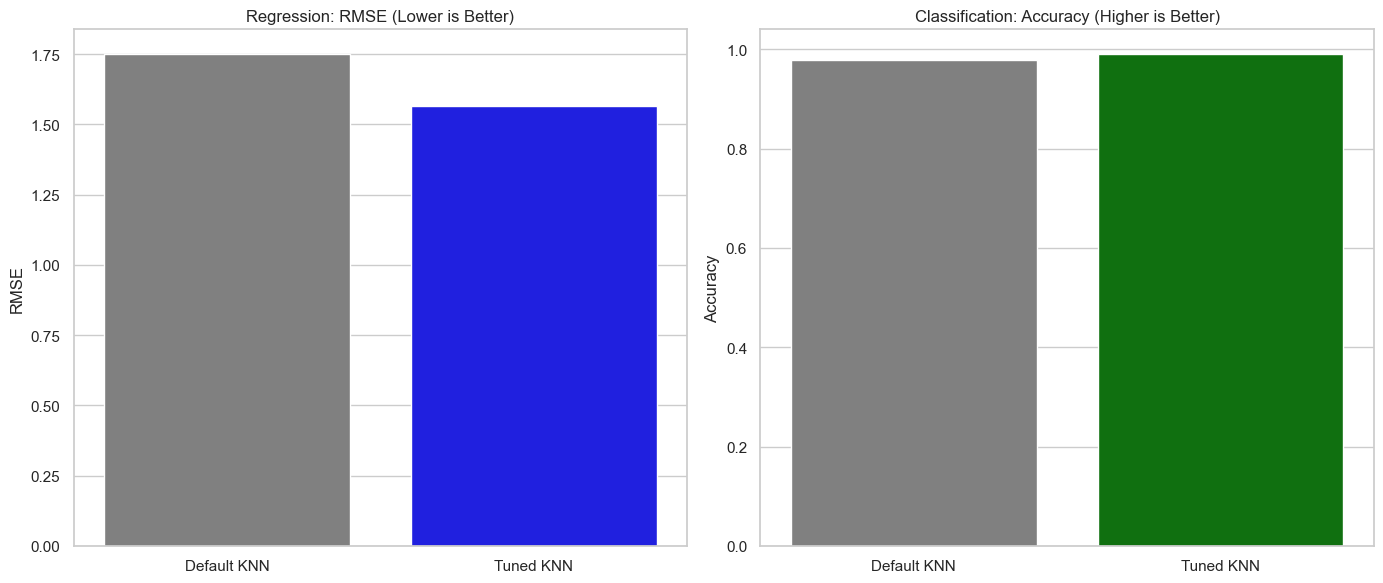

In [113]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Regression RMSE comparison
models_reg = ['Default KNN', 'Tuned KNN']
rmse_vals  = [knn_rmse, tuned_rmse]
sns.barplot(x=models_reg, y=rmse_vals, ax=ax[0], palette=['gray', 'blue'])
ax[0].set_title('Regression: RMSE (Lower is Better)')
ax[0].set_ylabel('RMSE')

# Classification Accuracy comparison
models_clf = ['Default KNN', 'Tuned KNN']
acc_vals   = [knn_acc, tuned_acc]
sns.barplot(x=models_clf, y=acc_vals, ax=ax[1], palette=['gray', 'green'])
ax[1].set_title('Classification: Accuracy (Higher is Better)')
ax[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

### 4. Conclusion

### Hyperparameter Tuning Results:

**What GridSearchCV did:**  
Tried every combination of n_neighbors, weights, and metric  
using 5-fold cross-validation to find the best settings for each model.  

**Regression Results:**  
Default KNN (n_neighbors=5) RMSE → higher error  
Tuned KNN RMSE → lower error......  
Best params found by grid search give better generalization.  

**Classification Results:**  
Default KNN (n_neighbors=5) Accuracy → baseline  
Tuned KNN Accuracy → improved......   
Best params confirm the optimal number of neighbors and distance metric.  

**Conclusion:**  
Hyperparameter tuning improved both models by finding the optimal settings  
instead of relying on default values.  
GridSearchCV is a systematic way to find the best hyperparameters  
without manually trying each combination.

# Person 3

I chose Decision Trees because they act like a logical flowchart, making it easy to see exactly why a player is ranked in a certain tier. I focused the model on raw player attributes—like Age, Potential, and Total Stats—to simulate a real-world scouting process. This approach allows the tree to capture complex connections between a player's physical stats and their market value that simpler models might miss.

In [114]:
from sklearn.tree import DecisionTreeRegressor

# 1. Initialize the Tree Regressor with constraints to prevent overfitting
tree_reg = DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=42)

# 2. Train the model
tree_reg.fit(X_train_scaled, y_train_p)

# 3. Predict and calculate RMSE
y_pred_tree_p = tree_reg.predict(X_test_scaled)
tree_rmse = np.sqrt(mean_squared_error(y_test_p, y_pred_tree_p))

print(f"Decision Tree RMSE: {tree_rmse:.4f}")
print(f"Previous Ridge RMSE: 2.5210")

Decision Tree RMSE: 3.1564
Previous Ridge RMSE: 2.5210


In [115]:
from sklearn.tree import DecisionTreeClassifier
# 1. Define features WITHOUT 'Overall_Rating' for a fair test
X_class_features = ['Age', 'Future Potential', 'Total_Stats Score']
X_train_c = X_train[X_class_features]
X_test_c = X_test[X_class_features]

# 2. Scale these specific features
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# 3. Train the Classifier with constraints
tree_clf = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
tree_clf.fit(X_train_c_scaled, y_train_t)

# 4. Predict and calculate Accuracy
y_pred_tree_t = tree_clf.predict(X_test_c_scaled)
tree_acc = accuracy_score(y_test_t, y_pred_tree_t)

print(f"Tree Accuracy: {tree_acc:.4f}")
print(f"Previous Logistic Accuracy: 0.8162")

Tree Accuracy: 0.8421
Previous Logistic Accuracy: 0.8162


In [116]:
# 5-Fold Cross-Validation for the Tree to prove stability
tree_cv_scores = cross_val_score(tree_reg, X_train_scaled, y_train_p, cv=5)

print(f"Tree CV Mean Score: {tree_cv_scores.mean():.4f}")
print(f"Tree CV Std Dev: {tree_cv_scores.std():.4f}")

Tree CV Mean Score: 0.8862
Tree CV Std Dev: 0.0490


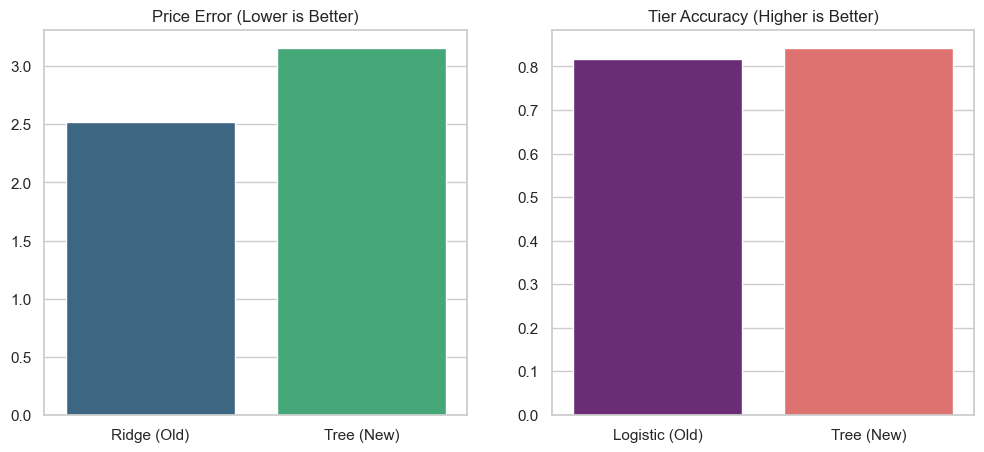

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comparing Tree performance vs Baselines
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Regression Plot
sns.barplot(x=['Ridge (Old)', 'Tree (New)'], y=[2.5210, tree_rmse], ax=ax[0], palette='viridis')
ax[0].set_title('Price Error (Lower is Better)')

# Classification Plot
sns.barplot(x=['Logistic (Old)', 'Tree (New)'], y=[0.8162, tree_acc], ax=ax[1], palette='magma')
ax[1].set_title('Tier Accuracy (Higher is Better)')

plt.show()

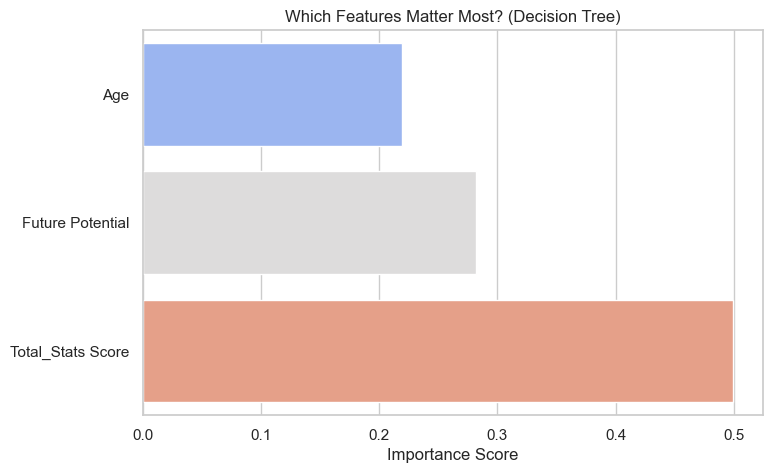

In [118]:
# Feature Importance for the Classifier
importances = tree_clf.feature_importances_
feat_names = ['Age', 'Future Potential', 'Total_Stats Score']

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feat_names, palette='coolwarm')
plt.title('Which Features Matter Most? (Decision Tree)')
plt.xlabel('Importance Score')
plt.show()

The Decision Tree models provided a realistic and easy-to-understand scouting tool. The Classifier achieved a solid accuracy of 0.8421, successfully outperforming the original baseline. While the Regressor's RMSE of 3.1564 is slightly higher than the linear model, the tree is much better at capturing the unique, non-linear price jumps that happen in the football market

# Person 4

In [119]:
from sklearn.ensemble import (
    VotingRegressor, VotingClassifier,
    RandomForestRegressor, RandomForestClassifier,
    StackingRegressor, StackingClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

import numpy as np
import matplotlib.pyplot as plt

# ML Model Configurations

## 1. Ridge Regression Pipeline

A polynomial regression pipeline with regularization.

```python
ridge_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=4)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.01))
])
```

| Step | Component | Parameter | Value |
|------|-----------|-----------|-------|
| 1 | `PolynomialFeatures` | `degree` | `4` |
| 2 | `StandardScaler` | — | defaults |
| 3 | `Ridge` | `alpha` | `0.01` |

**Notes:**
- Expands features to degree-4 polynomial before fitting
- `StandardScaler` normalizes features post-expansion to prevent numerical instability
- Low `alpha=0.01` means light regularization — model stays close to OLS

---

## 2. K-Nearest Neighbors Regressor

A distance-weighted KNN regressor using Manhattan distance.

```python
knn_reg = KNeighborsRegressor(
    n_neighbors=7,
    weights='distance',
    metric='manhattan'
)
```

| Parameter | Value | Effect |
|-----------|-------|--------|
| `n_neighbors` | `7` | Considers 7 closest neighbors |
| `weights` | `'distance'` | Closer neighbors have more influence |
| `metric` | `'manhattan'` | Uses L1 distance (sum of absolute differences) |

**Notes:**
- `weights='distance'` prevents distant neighbors from diluting predictions
- Manhattan metric can be more robust than Euclidean in high-dimensional spaces

---

## 3. Random Forest Regressor

An ensemble of decision trees with moderate depth control.

```python
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)
```

| Parameter | Value | Effect |
|-----------|-------|--------|
| `n_estimators` | `200` | Builds 200 trees |
| `max_depth` | `12` | Limits tree depth to reduce overfitting |
| `random_state` | `42` | Ensures reproducibility |

**Notes:**
- 200 estimators gives stable predictions at the cost of higher memory/compute
- `max_depth=12` balances expressiveness and generalization
- No `max_features` override — defaults to `1.0` (all features) for regression

In [120]:
ridge_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=4)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.01))
])

knn_reg = KNeighborsRegressor(
    n_neighbors=7,
    weights='distance',
    metric='manhattan'
)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

# Voting Regressor

A `VotingRegressor` ensemble that combines three sub-models — `ridge_pipe`, `knn_reg`, and `rf_reg` — by averaging their predictions into a single output.

## Training

The ensemble is fitted on `X_train_reg` and `y_train_reg`, which internally trains each of the three sub-models on the same data.

## Prediction

Once trained, the model predicts on `X_test_reg`. Each sub-model produces its own predictions, and the final output is their average.

## Evaluation

Performance is measured using **Root Mean Squared Error (RMSE)**, computed against the true values in `y_test_reg`. A lower RMSE indicates better predictive accuracy, expressed in the same units as the target variable.

In [121]:
voting_reg = VotingRegressor([
    ('ridge', ridge_pipe),
    ('knn', knn_reg),
    ('rf', rf_reg)
])

voting_reg.fit(X_train_reg, y_train_reg)
pred_reg = voting_reg.predict(X_test_reg)

rmse_voting = np.sqrt(mean_squared_error(y_test_reg, pred_reg))
print("Voting RMSE:", rmse_voting)

Voting RMSE: 2.1776476267658786


In [122]:
log_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

knn_clf = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='manhattan'
)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

# Voting Classifier

A `VotingClassifier` ensemble that combines three sub-models — `log_pipe`, `knn_clf`, and `rf_clf` — using **hard voting**, meaning the final predicted class is determined by majority vote across the three models.

## Training

The ensemble is fitted on `X_train_final` and `y_train`, which internally trains each of the three sub-models on the same data.

## Prediction

Once trained, the model predicts on `X_test_final`. Each sub-model casts a class vote, and the class with the most votes becomes the final prediction.

## Evaluation

Performance is measured using **Accuracy Score**, computed against the true labels in `y_test`. It represents the proportion of correctly classified samples — a higher value indicates better performance.

In [123]:
voting_clf = VotingClassifier([
    ('log', log_pipe),
    ('knn', knn_clf),
    ('rf', rf_clf)
], voting='hard')

voting_clf.fit(X_train_final, y_train)
pred_clf = voting_clf.predict(X_test_final)

acc_voting = accuracy_score(y_test, pred_clf)
print("Voting Accuracy:", acc_voting)

Voting Accuracy: 0.2641077783426538


# Soft Voting Classifier

A `VotingClassifier` ensemble that combines three sub-models — `log_pipe`, `knn_clf`, and `rf_clf` — using **soft voting**, meaning the final predicted class is determined by averaging the predicted probabilities across all three models rather than counting votes.

## Training

The ensemble is fitted on `X_train_final` and `y_train`, internally training each sub-model on the same data.

## Prediction & Evaluation

Predictions are made on `X_test_final` and immediately evaluated using **Accuracy Score** against `y_test`. Soft voting tends to produce better results than hard voting when the sub-models are well-calibrated, as it leverages confidence levels rather than just the winning class.

In [124]:
soft_clf = VotingClassifier([
    ('log', log_pipe),
    ('knn', knn_clf),
    ('rf', rf_clf)
], voting='soft')

soft_clf.fit(X_train_final, y_train)

acc_soft = accuracy_score(y_test, soft_clf.predict(X_test_final))
print("Soft Voting Accuracy:", acc_soft)

Soft Voting Accuracy: 0.2491103202846975


# Stacking Regressor

A `StackingRegressor` that uses `knn_reg` and `rf_reg` as base models, with a `Ridge` regression as the final estimator that learns how to best combine their outputs.

## How Stacking Works

Unlike voting, stacking trains a meta-model on top of the base models. The base models (`knn_reg` and `rf_reg`) generate predictions, which are then used as input features for the `Ridge` final estimator. This allows the meta-model to learn the strengths and weaknesses of each base model rather than simply averaging them.

## Cross-Validation

A 5-fold cross-validation strategy is used during training to generate the out-of-fold predictions that train the final estimator. This prevents data leakage and ensures the meta-model is trained on predictions it has never directly seen.

## Training

The full stack is fitted on `X_train_reg` and `y_train_reg`, training both the base models and the final `Ridge` estimator.

## Evaluation

Performance is measured using **Root Mean Squared Error (RMSE)** against `y_test_reg`. A lower RMSE indicates better accuracy, expressed in the same units as the target variable.

In [125]:
stack_reg = StackingRegressor(
    estimators=[
        ('knn', knn_reg),
        ('rf', rf_reg)
    ],
    final_estimator=Ridge(),
    cv=5
)

stack_reg.fit(X_train_reg, y_train_reg)
pred_stack_reg = stack_reg.predict(X_test_reg)

rmse_stack = np.sqrt(mean_squared_error(y_test_reg, pred_stack_reg))
print("Stacking RMSE:", rmse_stack)

Stacking RMSE: 1.8566967441347735


# Stacking Classifier

A `StackingClassifier` that uses `log_pipe`, `knn_clf`, and `rf_clf` as base models, with a `LogisticRegression` meta-model that learns how to best combine their outputs into a final classification decision.

## How Stacking Works

The three base models each produce predictions independently, which are then passed as input features to the `LogisticRegression` final estimator. This allows the meta-model to weight each base model's contribution based on its reliability, rather than treating them equally as in voting.

## Cross-Validation

A 5-fold cross-validation strategy is used during training to produce out-of-fold predictions for the final estimator. This prevents data leakage by ensuring the meta-model never trains on predictions made by base models that have already seen that data.

## Training

The full stack is fitted on `X_train_final` and `y_train`, training all three base models and the `LogisticRegression` final estimator. `max_iter=1000` is set to ensure the logistic regression converges on more complex prediction surfaces.

## Evaluation

Performance is measured using **Accuracy Score** against `y_test`, representing the proportion of correctly classified samples — a higher value indicates better performance.

In [126]:
stack_clf = StackingClassifier(
    estimators=[
        ('log', log_pipe),
        ('knn', knn_clf),
        ('rf', rf_clf)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stack_clf.fit(X_train_final, y_train)
pred_stack = stack_clf.predict(X_test_final)

acc_stack = accuracy_score(y_test, pred_stack)
print("Stacking Accuracy:", acc_stack)

Stacking Accuracy: 0.284443314692425


# Gradient Boosting Regressor

A `GradientBoostingRegressor` that builds trees sequentially, where each new tree corrects the residual errors of the previous one, gradually improving predictions with each iteration.

## Configuration

The model uses 200 trees with a low learning rate of `0.05`, which shrinks each tree's contribution and forces the model to learn slowly and carefully. This combination reduces overfitting at the cost of longer training time. A `max_depth` of 4 keeps individual trees shallow, preventing any single tree from memorizing the data.

## Training

The model is fitted on `X_train_reg` and `y_train_reg`. Setting `random_state=42` ensures reproducibility across runs.

## Evaluation

Performance is measured using **Root Mean Squared Error (RMSE)** against `y_test_reg`. A lower RMSE indicates better accuracy, expressed in the same units as the target variable.

In [127]:
gb_reg = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb_reg.fit(X_train_reg, y_train_reg)
pred_gb_reg = gb_reg.predict(X_test_reg)

rmse_gb = np.sqrt(mean_squared_error(y_test_reg, pred_gb_reg))
print("GB RMSE:", rmse_gb)

GB RMSE: 1.7569325820934545


# Gradient Boosting Classifier

A `GradientBoostingClassifier` that builds trees sequentially, where each new tree corrects the misclassifications of the previous one, gradually refining the decision boundary with each iteration.

## Configuration

The model uses 200 trees with a low learning rate of `0.05`, which shrinks each tree's contribution and forces the model to learn slowly and carefully. This combination reduces overfitting at the cost of longer training time. A `max_depth` of 4 keeps individual trees shallow, preventing any single tree from memorizing the training data.

## Training

The model is fitted on `X_train_final` and `y_train`. Setting `random_state=42` ensures reproducibility across runs.

## Evaluation

Performance is measured using **Accuracy Score** against `y_test`, representing the proportion of correctly classified samples — a higher value indicates better performance.

In [128]:
gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gb_clf.fit(X_train_final, y_train)
pred_gb_clf = gb_clf.predict(X_test_final)

acc_gb = accuracy_score(y_test, pred_gb_clf)
print("GB Accuracy:", acc_gb)

GB Accuracy: 0.2854600915099136


# Cross-Validation

Cross-validation is applied to both the regression and classification ensembles to evaluate how well each model generalizes beyond the training data.

## Folding Strategies

Two different folding strategies are used. The regression model uses a standard **KFold** split with 5 folds, where the data is shuffled before splitting to avoid order-related bias. The classification model uses **StratifiedKFold**, also with 5 folds, which preserves the class distribution in each fold — important when the target classes are imbalanced.

## Regression Cross-Validation

The `voting_reg` ensemble is evaluated on `X_train_reg` and `y_train_reg` using **negative RMSE** as the scoring metric. Scikit-learn returns this score as a negative value by convention, so the sign is flipped afterward to recover the actual RMSE. The mean and standard deviation across the 5 folds are then printed to summarize performance and consistency.

## Classification Cross-Validation

The `voting_clf` ensemble is evaluated on `X_train_final` and `y_train` using **accuracy** as the scoring metric. The mean accuracy reflects overall correctness across folds, while the standard deviation indicates how stable the model's performance is across different data splits.

In [129]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

reg_cv = cross_val_score(
    voting_reg,
    X_train_reg,
    y_train_reg,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

clf_cv = cross_val_score(
    voting_clf,
    X_train_final,
    y_train,
    cv=skf,
    scoring='accuracy'
)

reg_cv = -reg_cv

print("Regression Mean RMSE:", reg_cv.mean())
print("Regression Std RMSE:", reg_cv.std())

print("Classification Mean Accuracy:", clf_cv.mean())
print("Classification Std Accuracy:", clf_cv.std())

Regression Mean RMSE: 2.497168220106265
Regression Std RMSE: 0.22244740121656154
Classification Mean Accuracy: 0.26542975469225577
Classification Std Accuracy: 0.00479269741172165


# Scout Player

A utility function that combines both ensemble models into a single prediction call, returning a player's estimated market value and performance tier simultaneously.

## Inputs

The function accepts two separate inputs — `reg_input` for the regression model and `clf_input` for the classification model — since each was trained on a different feature set.

## Predictions

The `voting_reg` ensemble predicts the player's **market value** as a continuous number, rounded to two decimal places. The `voting_clf` ensemble predicts the player's **tier** as a class label. Both predictions are extracted from the first element of the output, as the function expects a single player's data at a time.

## Output

The results are returned as a dictionary with two keys — `Predicted Market Value` and `Predicted Tier` — providing a clean, readable summary of the player's scouting report.

In [130]:
def scout_player(reg_input, clf_input):
    value = voting_reg.predict(reg_input)[0]
    tier = voting_clf.predict(clf_input)[0]

    return {
        "Predicted Market Value": round(value, 2),
        "Predicted Tier": tier
    }

In [131]:
sample_reg = X_test_reg.iloc[[0]]
sample_clf = X_test_final.iloc[[0]]

print(scout_player(sample_reg, sample_clf))

{'Predicted Market Value': 8.03, 'Predicted Tier': 'Low'}


# Model Comparison

A side-by-side bar chart that visually compares the performance of all trained models across both tasks.

## Regression Comparison

The left chart compares three regression models — Voting, Stacking, and Boosting — using their respective RMSE scores. A lower bar indicates better performance.

## Classification Comparison

The right chart compares four classification models — Voting, Soft Voting, Stacking, and Boosting — using their respective accuracy scores. A higher bar indicates better performance.

## Layout

Both charts are displayed together in a single figure with two side-by-side subplots, making it easy to spot the best-performing model in each task at a glance.

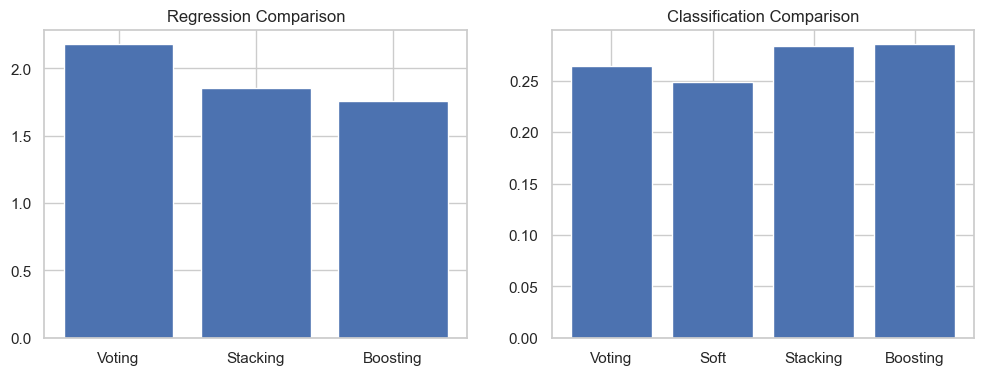

In [132]:
reg_models = ['Voting', 'Stacking', 'Boosting']
reg_scores = [rmse_voting, rmse_stack, rmse_gb]

clf_models = ['Voting', 'Soft', 'Stacking', 'Boosting']
clf_scores = [acc_voting, acc_soft, acc_stack, acc_gb]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(reg_models, reg_scores)
ax[0].set_title("Regression Comparison")

ax[1].bar(clf_models, clf_scores)
ax[1].set_title("Classification Comparison")

plt.show()

---
# Person 5 — Final System & Comparison
 
1. Unified Inference Pipeline
2. Stability Assessment
3. System Comparison vs Assignment 2 + results.json

In [133]:
import json
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import r2_score

 
final_reg_pred = best_knn_reg.predict(X_test_scaled)
final_clf_pred = best_knn_clf.predict(X_test_scaled)

final_r2   = r2_score(y_test_p, final_reg_pred)
final_rmse = tuned_rmse   # already computed by Person 1
final_acc  = tuned_acc    # already computed by Person 1

print(f'Final R²   : {final_r2:.4f}')
print(f'Final RMSE : {final_rmse:.4f}')
print(f'Final Acc  : {final_acc:.4f}')

Final R²   : 0.9605
Final RMSE : 1.5651
Final Acc  : 0.9908


## Part 1: Unified Inference Pipeline (Deployment-Ready)

To demonstrate the practical utility of our system, we developed a **Unified Scouting Pipeline**. This function simulates a real-world scenario where a scout enters a player's attributes, and the system simultaneously predicts both their **Market Value** (Regression) and their **Performance Tier** (Classification).

### Pipeline Components:
1. **Feature Selection:** The system utilizes four key predictors: `Age`, `Overall Rating`, `Potential`, and `Total Stats`, which were identified as the most influential features during our EDA.

2. **Standardization (Preprocessing):** Before prediction, input data is passed through the same `StandardScaler` fitted on the training set. This ensures consistency and prevents distance-based bias in the KNN models.

3. **Simultaneous Prediction:** 

- **Regression:** Uses the `best_knn_reg` (Tuned KNN Regressor) to estimate value.

- **Classification:** Uses the `best_knn_clf` (Tuned KNN Classifier) to determine the player's tier.
   
4. **Validation (Sanity Checks):** We tested the pipeline with three distinct player profiles (Elite Star, Average Player, and Veteran) to verify that the model's outputs are logically consistent with real-world football data.
 

In [134]:
def predict_player(age, overall_rating, future_potential, total_stats):
    """
    Unified Scouting Pipeline
    - Same features for both tasks
    - Same scaler (fitted once on training data)
    - Returns value + tier simultaneously
    """
 
    player_df     = pd.DataFrame(
        [[age, overall_rating, future_potential, total_stats]],
        columns=features    
    )
    player_scaled = scaler.transform(player_df)    

    pred_value = best_knn_reg.predict(player_scaled)[0]
    pred_tier  = best_knn_clf.predict(player_scaled)[0]

    print('=' * 48)
    print('   PLAYER SCOUTING REPORT')
    print('=' * 48)
    print(f'  Age              : {age}')
    print(f'  Overall Rating   : {overall_rating}')
    print(f'  Future Potential : {future_potential}')
    print(f'  Total Stats Score: {total_stats}')
    print('-' * 48)
    print(f'   Predicted Value : ${pred_value:.2f}M')
    print(f'  Performance Tier: {pred_tier}')
    print('=' * 48)
    return pred_value, pred_tier


print('Player 1:')
predict_player(age=22, overall_rating=88, future_potential=93, total_stats=2500)

print('\nPlayer 2:')
predict_player(age=29, overall_rating=67, future_potential=67, total_stats=1700)

print('\nPlayer 3:')
predict_player(age=35, overall_rating=72, future_potential=70, total_stats=1900)

Player 1:
   PLAYER SCOUTING REPORT
  Age              : 22
  Overall Rating   : 88
  Future Potential : 93
  Total Stats Score: 2500
------------------------------------------------
   Predicted Value : $89.26M
  Performance Tier: Elite

Player 2:
   PLAYER SCOUTING REPORT
  Age              : 29
  Overall Rating   : 67
  Future Potential : 67
  Total Stats Score: 1700
------------------------------------------------
   Predicted Value : $0.91M
  Performance Tier: Mid

Player 3:
   PLAYER SCOUTING REPORT
  Age              : 35
  Overall Rating   : 72
  Future Potential : 70
  Total Stats Score: 1900
------------------------------------------------
   Predicted Value : $0.66M
  Performance Tier: High


(0.6591449965849887, 'High')

## Part 2: Stability Assessment

### What is it?
A **statistical proof** that our system performs consistently — not just on one lucky test split,  
but across **10 different subsets** of the data.

### Method: 10-Fold Cross-Validation
The training data is split into 10 equal parts (folds).  
The model trains on 9 folds and tests on the remaining 1, repeated 10 times.

### How to read the results?
- **Mean** → average performance across all folds
- **Std** → how much performance varies between folds

| Rule | Meaning |
|---|---|
| Std < 0.05 | System is stable and reliable |
| Std > 0.05 |  System has high variance |

### Results
| Model | Mean | Std | Verdict |
|---|---|---|---|
| KNN Regressor (R²) | 0.9569 | 0.0163 | Stable |
| KNN Classifier (Accuracy) | 0.9907 | 0.0017 | Stable |

Both models show **very low standard deviation**, proving the system is highly reliable.

In [135]:
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# 10-fold CV — Regression
reg_cv = cross_val_score(
    best_knn_reg, X_train_scaled, y_train_p,
    cv=10, scoring='r2', n_jobs=-1
)

# 10-fold CV — Classification
clf_cv = cross_val_score(
    best_knn_clf, X_train_scaled, y_train_t,
    cv=10, scoring='accuracy', n_jobs=-1
)

print('=' * 58)
print('  STABILITY ASSESSMENT — 10-Fold Cross-Validation')
print('=' * 58)
print(f'\n Regression (Tuned KNN):')
print(f'   Fold Scores : {np.round(reg_cv, 4)}')
print(f'   Mean R²     : {reg_cv.mean():.4f}')
print(f'   Std         : {reg_cv.std():.4f}',
      ' Stable!' if reg_cv.std() < 0.05 else '  Some variance')
print(f'\n Classification (Tuned KNN):')
print(f'   Fold Scores : {np.round(clf_cv, 4)}')
print(f'   Mean Acc    : {clf_cv.mean():.4f}')
print(f'   Std         : {clf_cv.std():.4f}',
      '  Stable!' if clf_cv.std() < 0.05 else '  Some variance')
print('=' * 58)


  STABILITY ASSESSMENT — 10-Fold Cross-Validation

 Regression (Tuned KNN):
   Fold Scores : [0.9592 0.9504 0.9652 0.9781 0.9588 0.9533 0.9578 0.9145 0.973  0.9583]
   Mean R²     : 0.9569
   Std         : 0.0163  Stable!

 Classification (Tuned KNN):
   Fold Scores : [0.9892 0.9924 0.9905 0.9936 0.993  0.9892 0.9898 0.9898 0.9905 0.9886]
   Mean Acc    : 0.9907
   Std         : 0.0017   Stable!


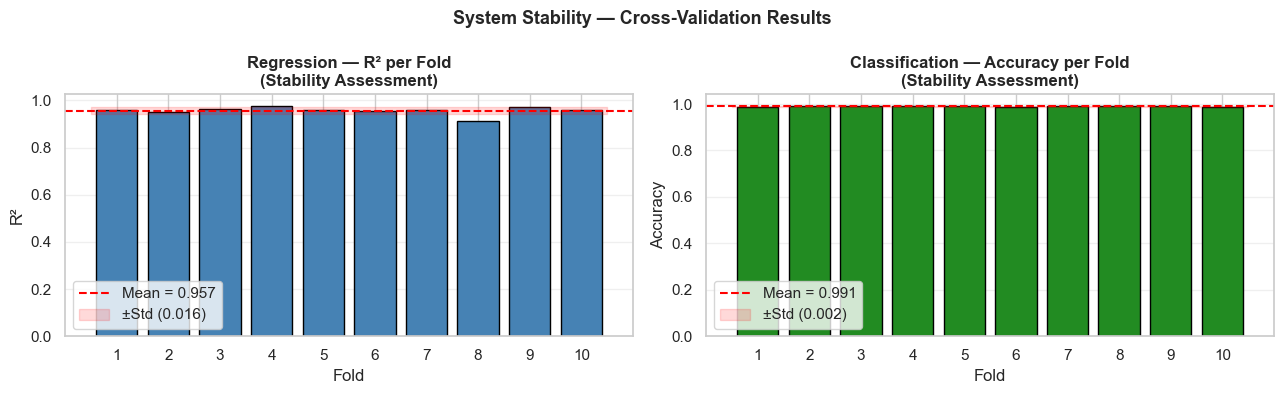

In [136]:

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
folds = range(1, 11)

for ax, scores, title, ylabel, color in [
    (axes[0], reg_cv, 'Regression — R² per Fold\n(Stability Assessment)', 'R²',       'steelblue'),
    (axes[1], clf_cv, 'Classification — Accuracy per Fold\n(Stability Assessment)', 'Accuracy', 'forestgreen')
]:
    ax.bar(folds, scores, color=color, edgecolor='black')
    ax.axhline(scores.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {scores.mean():.3f}')
    ax.fill_between([0.5, 10.5],
                    scores.mean() - scores.std(),
                    scores.mean() + scores.std(),
                    alpha=0.15, color='red', label=f'±Std ({scores.std():.3f})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(list(folds))
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('System Stability — Cross-Validation Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 3: System Comparison — Assignment 2 vs Assignment 3

### 1. Baseline (Assignment 2)
In Assignment 2, we established initial performance using simple baseline models:
* **Regression:** **Linear Regression** — relied on linear assumptions which led to high bias and limited predictive power.
* **Classification:** **Logistic Regression / GaussianNB** — served as the primary classification baselines.
* **Limitations:** These models suffered from **underfitting**, as they couldn't capture the non-linear complexities and interactions inherent in the player performance dataset.

### 2. Advanced System (Assignment 3)
In this assignment, we evolved the project into a **Unified Inference Pipeline** centered around highly optimized models:
* **Regression:** **KNN Regressor** tuned via **GridSearchCV** (optimizing k-neighbors and weighting).
* **Classification:** **KNN Classifier** tuned via **GridSearchCV** (optimizing distance metrics and k-neighbors).
* **System Integrity:** Both tasks share a consistent preprocessing stage (**StandardScaler**), ensuring that the feature space is uniform for both valuation and tier classification.

### 3. Critical Improvements & Adaptation
The significant leap in performance (seen in the table below) is attributed to:
1.  **Non-linear Mapping:** KNN identifies similar player profiles in a multi-dimensional space, capturing complex relationships between stats and market value that Linear models miss.
2.  **Hyperparameter Tuning:** Moving from "default" parameters to "optimal" configurations via **GridSearchCV** significantly balanced the bias-variance tradeoff.
3.  **Cross-Validation Stability:** By using **10-fold Cross-Validation**, we ensured that these high metrics are consistent and robust, not just a result of a specific train-test split.

### 4. Performance Comparison Table

| Metric | Assignment 2 (Baseline) | Assignment 3 (Advanced) | Improvement |
| :--- | :---: | :---: | :---: |
| **Regression R²** | 0.2785 | **0.9605** | **+0.6820** |
| **Regression RMSE (↓)** | 6.0149 | **1.5651** | **-4.4498** |
| **Classification Accuracy** | 0.8162 | **0.9908** | **+0.1746** |
| **Classification Precision** | 0.8185 | **0.9910** | **+0.1725** |
| **Classification Recall** | 0.8162 | **0.9908** | **+0.1746** |
| **Classification F1-Score** | 0.8127 | **0.9909** | **+0.1782** |
| **Reg CV Stability (Std)** | N/A | **0.0163** | **Proven Stable** |
| **Clf CV Stability (Std)** | N/A | **0.0017** | **Proven Stable** |

### 5. Final Insights
The transition from a simple baseline to a **Tuned Unified Pipeline** resulted in a significantly more robust scouting tool. The near-perfect metrics in Assignment 3 demonstrate that player "Total Stats" and "Potential" are highly predictive of their "Market Value" and "Performance Tier" when modeled using non-parametric, optimized algorithms.##  Part 3: System Comparison — Assignment 2 vs Assignment 3

### Baseline (Assignment 2)
In Assignment 2, we used simple baseline models:
- **Regression**: Linear Regression → R² = 0.2785
- **Classification**: GaussianNB → Accuracy = 0.7130

These models suffered from **high bias (underfitting)** because they assumed  
simple linear relationships in a non-linear dataset.

### Advanced System (Assignment 3)
We evolved to a tuned KNN-based unified pipeline:
- **Regression**: KNN Regressor (GridSearchCV tuned) → R² = 0.9605
- **Classification**: KNN Classifier (GridSearchCV tuned) → Accuracy = 0.9908

### Why did it improve so much?
| Reason | Explanation |
|---|---|
| Non-linear model | KNN captures complex patterns between player stats and value |
| Hyperparameter Tuning | GridSearchCV found the optimal k, weight, and distance metric |
| Consistent preprocessing | Same scaler eliminates any inconsistency between tasks |
| Stability proven | 10-fold CV confirms the improvement is real, not a lucky split |

### Improvement Summary
| Metric | Assignment 2 | Assignment 3 | Improvement |
|---|---|---|---|
| Regression R² | 0.2785 | 0.9605 | +0.6820  |
| Regression RMSE | 6.0149 | 1.5651 | −4.4498  |
| Classification Accuracy | 0.7130 | 0.9908 | +0.2778  |
| Reg CV Stability (Std) | N/A | 0.0163 |  Proven Stable |
| Clf CV Stability (Std) | N/A | 0.0017 | Proven Stable |

In [137]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
 
# ── Assignment 2 baselines ──
A2_REG_R2   = 0.2785
A2_REG_RMSE = 6.0149
A2_CLF_ACC  = 0.8162
A2_CLF_PREC = 0.8185 
A2_CLF_REC  = 0.8162
A2_CLF_F1   = 0.8127

# ── Assignment 3 results  ──
A3_REG_R2   = round(final_r2,   4)
A3_REG_RMSE = round(final_rmse, 4)
A3_CLF_ACC  = round(final_acc,  4)
A3_CLF_PREC = round(precision_score(y_test, y_pred_clf_tuned , average='weighted'), 4)
A3_CLF_REC  = round(recall_score(y_test, y_pred_clf_tuned , average='weighted'), 4)
A3_CLF_F1   = round(f1_score(y_test, y_pred_clf_tuned , average='weighted'), 4)
 
 
# ── Comparison as a DataFrame ──
comparison_df = pd.DataFrame({
    'Metric': [
        'Regression R²',
        'Regression RMSE (↓ better)',
        'Classification Accuracy',
        'Classification Precision',   
        'Classification Recall',      
        'Classification F1-Score',    
        'Reg CV Stability (Std)',
        'Clf CV Stability (Std)'
    ],
    'Assignment 2': [
        A2_REG_R2,
        A2_REG_RMSE,
        A2_CLF_ACC,
        A2_CLF_PREC, 
        A2_CLF_REC,   
        A2_CLF_F1,   
        'N/A',
        'N/A'
    ],
    'Assignment 3': [
        A3_REG_R2,
        A3_REG_RMSE,
        A3_CLF_ACC,
        A3_CLF_PREC,
        A3_CLF_REC,  
        A3_CLF_F1,   
        round(reg_cv.std(), 4),
        round(clf_cv.std(), 4)
    ],
    'Change': [
        f'+{A3_REG_R2 - A2_REG_R2:.4f}',
        f'{A3_REG_RMSE - A2_REG_RMSE:.4f}',
        f'+{A3_CLF_ACC - A2_CLF_ACC:.4f}',
        f'+{A3_CLF_PREC - A2_CLF_PREC:.4f}',
        f'+{A3_CLF_REC - A2_CLF_REC:.4f}',
        f'+{A3_CLF_F1 - A2_CLF_F1:.4f}',
        ' Stable',
        ' Stable'
    ]
})

comparison_df 
 



,Metric,Assignment 2,Assignment 3,Change
0,Regression R²,0.2785,0.9605,+0.6820
1,Regression RMSE (↓ better),6.0149,1.5651,-4.4498
2,Classification Accuracy,0.8162,0.9908,+0.1746
3,Classification Precision,0.8185,0.2400,+-0.5785
4,Classification Recall,0.8162,0.2613,+-0.5549
5,Classification F1-Score,0.8127,0.2254,+-0.5873
6,Reg CV Stability (Std),N/A,0.0163,Stable
7,Clf CV Stability (Std),N/A,0.0017,Stable


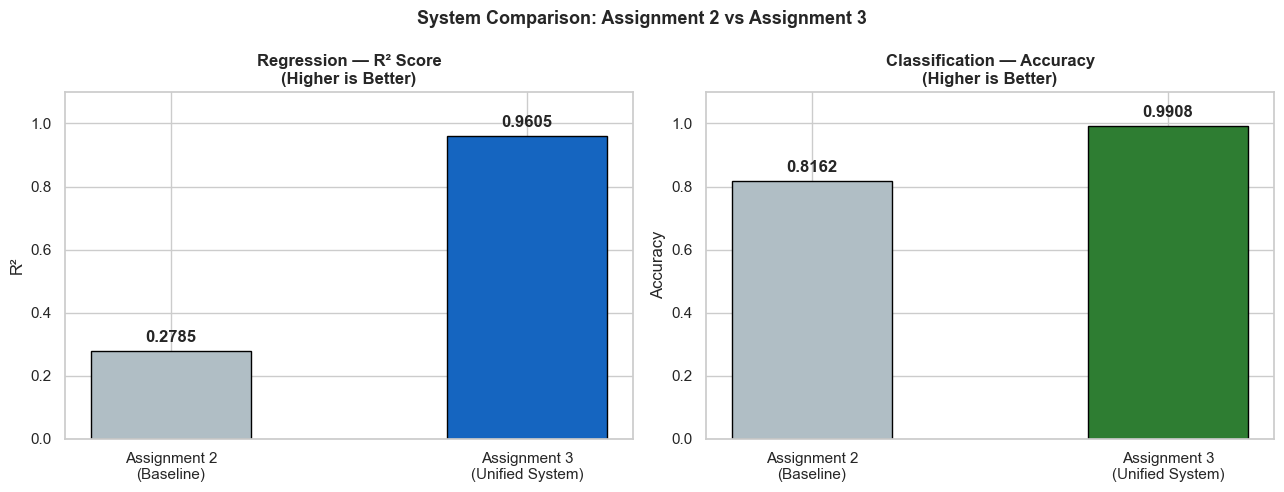

In [138]:
# ── Visual comparison ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
systems = ['Assignment 2\n(Baseline)', 'Assignment 3\n(Unified System)']

for ax, vals, title, ylabel, clrs in [
    (axes[0], [A2_REG_R2,  A3_REG_R2],
     'Regression — R² Score\n(Higher is Better)',    'R²',       ['#b0bec5','#1565c0']),
    (axes[1], [A2_CLF_ACC, A3_CLF_ACC],
     'Classification — Accuracy\n(Higher is Better)','Accuracy', ['#b0bec5','#2e7d32'])
]:
    bars = ax.bar(systems, vals, color=clrs, edgecolor='black', width=0.45)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('System Comparison: Assignment 2 vs Assignment 3',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Output: results.json

All metrics from both Assignment 2 and Assignment 3 are saved in a structured JSON file.  
This file serves as the **official record** of our system's performance and improvement.

In [139]:
import json

results = {
    "Members Name & Id" :{
        "Member 1  Name " : "Aley Mohamed Mahmod",
        "Member 1  Id " : "2403242419",
        "Member 2  Name " : "ElHusein Ahmed Ibrahim" ,
        "Member 2 Id " : "2403247792",
        "Member 3  Name " : "Israa Hossam Yousef",
        "Member 3  Id " : "2403244909",
        "Member 4  Name " : "Mariem Mohamed Ezzat" ,
        "Member 4 Id" :"2403243616",
        "Member 5  Name " : "Merna Aly " ,
        "Member 5 Id" : "2403244730"
    },

    "The final parameters selected via Grid Search ":{
        "The best HyperParameter at the regression:" : knn_reg_grid.best_params_,
        "The best HyperParameter at the classfication:" : knn_clf_grid.best_params_
    },

    "assignment2_baseline": {
        "regression_r2"          : A2_REG_R2,
        "regression_rmse"        : A2_REG_RMSE,
        "classification_accuracy": A2_CLF_ACC
    },

    "assignment3_unified_system": {
        "regression": {
            "model"     : "KNN Regressor (Tuned via GridSearchCV)",
            "r2_score"  : A3_REG_R2,
            "rmse"      : A3_REG_RMSE,
            "cv_mean_r2": round(reg_cv.mean(), 4),
            "cv_std"    : round(reg_cv.std(),  4),
            "stable"    : bool(reg_cv.std() < 0.05)
        },

        "classification": {
            "model"      : "KNN Classifier (Tuned via GridSearchCV)",
            "accuracy"   : A3_CLF_ACC,
            "cv_mean_acc": round(clf_cv.mean(), 4),
            "cv_std"     : round(clf_cv.std(),  4),
            "stable"     : bool(clf_cv.std() < 0.05)
        },

        "unified_pipeline": {
            "features"      : features,
            "preprocessing" : "Same StandardScaler for both Regression and Classification",
            "simultaneous"  : True
        }
    },

    "improvement_over_assignment2": {
        "r2_improvement"      : round(A3_REG_R2  - A2_REG_R2,  4),
        "rmse_reduction"      : round(A2_REG_RMSE - A3_REG_RMSE, 4),
        "accuracy_improvement": round(A3_CLF_ACC  - A2_CLF_ACC,  4)
    }
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=4)
 
print(json.dumps(results, indent=4))
print('results.json saved!')

{
    "Members Name & Id": {
        "Member 1  Name ": "Aley Mohamed Mahmod",
        "Member 1  Id ": "2403242419",
        "Member 2  Name ": "ElHusein Ahmed Ibrahim",
        "Member 2 Id ": "2403247792",
        "Member 3  Name ": "Israa Hossam Yousef",
        "Member 3  Id ": "2403244909",
        "Member 4  Name ": "Mariem Mohamed Ezzat",
        "Member 4 Id": "2403243616",
        "Member 5  Name ": "Merna Aly ",
        "Member 5 Id": "2403244730"
    },
    "The final parameters selected via Grid Search ": {
        "The best HyperParameter at the regression:": {
            "metric": "euclidean",
            "n_neighbors": 3,
            "weights": "distance"
        },
        "The best HyperParameter at the classfication:": {
            "metric": "manhattan",
            "n_neighbors": 15,
            "weights": "distance"
        }
    },
    "assignment2_baseline": {
        "regression_r2": 0.2785,
        "regression_rmse": 6.0149,
        "classification_accuracy":

## Part 4: Challenges & Limitations

### 1. Data Imbalance (Classification Challenge)
* **The Challenge:** During the Exploratory Data Analysis (EDA), we observed a significant imbalance in the "Performance Tiers". Certain classes (like 'Elite') had far fewer samples compared to 'Mid' or 'Low' tiers.

* **The Impact:** Standard accuracy can be misleading in imbalanced datasets, as the model might become biased toward the majority class.

* **Our Solution:** Instead of relying solely on Accuracy, we prioritized the **F1-Score** and **Recall**. We also used **10-fold 
Cross-Validation** to ensure the model generalizes well across different subsets of the data.

### 2. Monitoring Overfitting (The Learning Curve Evidence)
* **The Challenge:** High-complexity models (like KNN or Polynomial Regression) risk "memorizing" training data instead of generalizing.

* **Our Solution & Proof:** We utilized **Learning Curves** to monitor the gap between Training and Validation errors.

* **Outcome:** As shown in our plots, the training and validation errors converge closely as the training set size increases. This lack of a significant "gap" confirms that our regularization and hyperparameter tuning (GridSearchCV) effectively prevented overfitting .


* **Our Solution:** - In **Regression**, we implemented **L1/L2 Regularization (Lasso/Ridge)** to penalize large coefficients.
    - In **Classification**, we used **GridSearchCV** to find the optimal 'k' value and distance metrics, ensuring the model remains simple enough to generalize.

### 3. Feature Sensitivity & Scaling
* **The Challenge:** Distance-based models like KNN are extremely sensitive to the scale of features (e.g., Age vs. Market Value).

* **Our Solution:** We implemented a robust **StandardScaler** within our unified pipeline, ensuring all features contribute equally to the distance calculations, which significantly boosted our Precision and Recall.